## ISYE 6740 - Assignment 1 - Regression

#### As we explore exciting new developments in AI, I want to provide some guidance around using chatbots like ChatGPT for our class assignments. 

#### The assignments are intended to develop your own skills and understanding. I encourage you to use ChatGPT liberally as a learning tool - discussing prompts and solutions with it can provide valuable insight into the problems. While ChatGPT can assist, make sure you are deeply engaged in working through the problems yourself. Take time to carefully review any suggestions from ChatGPT before submitting, and feel free to email me any prompts you find helpful. 

#### While directly copying ChatGPT solutions into assignments is not prohibited, I advise using discretion and care when relying on its outputs. The goal is to leverage this technology to enhance your learning, but not replace the thinking required, as I believe you do not want to regret being unable to answer machine learning questions well in a job interview.

### Please leave the name of your teammate here if applicable.

### Reproducibility

Run the cells from top to bottom using Python 3. Keep the original data files in the notebook directory or a `data/` subdirectory. All numerical answers and figures below were produced by the included code. Training and testing sets are kept as provided. Scaling is fitted only on training features, and the simulation uses a fixed random seed. Package versions are printed below.

In [1]:
# Teammate name (if applicable):

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import sklearn
from IPython.display import display, Markdown
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from threadpoolctl import threadpool_limits

# Avoid excessive BLAS/OpenMP threading on these small educational datasets.
_thread_limit = threadpool_limits(limits=1)

# Keep the supplied data beside this notebook, or in a data/ subdirectory.
DATA_DIR = Path('data') if Path('data/Q1_train.xls').is_file() else Path('.')

def load_xy(filename):
    path = DATA_DIR / filename
    frame = (pd.read_excel(path, engine='xlrd') if path.suffix == '.xls'
             else pd.read_csv(path))
    if frame.isna().any().any():
        raise ValueError(f'Missing values in {filename}')
    values = frame.to_numpy(dtype=float)
    if not np.isfinite(values).all():
        raise ValueError(f'Nonfinite values in {filename}')
    return values[:, :-1], values[:, -1], list(frame.columns[:-1])

plt.rcParams.update({'figure.figsize': (8, 4.8), 'figure.dpi': 120,
                     'axes.grid': True, 'grid.alpha': 0.25,
                     'font.size': 11, 'axes.spines.top': False,
                     'axes.spines.right': False})
pd.set_option('display.max_columns', 12)
pd.set_option('display.width', 140)
pd.set_option('display.precision', 6)
print(f'Python {sys.version.split()[0]}; NumPy {np.__version__}; '
      f'pandas {pd.__version__}; SciPy {scipy.__version__}; '
      f'scikit-learn {sklearn.__version__}')

Python 3.12.14; NumPy 2.3.5; pandas 3.0.1; SciPy 1.18.1; scikit-learn 1.9.1


### 1. OLS Linear Regression

* In this question, we use a dataset of concrete (`Q1_train.xls` and `Q1_test.xls`, read them with `pandas.read_excel`) to study OLS linear regression. For both training and testing data, the first 8 columns are features of concrete and the last column is "Concrete compressive strength". We will train a linear regression model to predict the target variable of "Concrete compressive strength".
* Please refer to the following package for OLS linear regression:
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html
* For this regression problem, we use Mean Square Error (MSE) as the metric to evaluate the performance of trained models. Given $n$ samples, let $\{Y_i\}_{i=1}^n$ be the observed values of the variable being predicted and $\{\hat{Y}_i\}_{i=1}^n$ be the predicted values. Then the MSE of the predictor is computed as 
<center>$\text{MSE} = \frac{1}{n} \sum_{i=1}^n (Y_i-\hat{Y}_i)^2$.</center>

#### a) Train a linear regression model using the training set and report the training MSE.

In [2]:
q1_X_train, q1_y_train, q1_features = load_xy('Q1_train.xls')
q1_X_test, q1_y_test, _ = load_xy('Q1_test.xls')
q1_ols = LinearRegression().fit(q1_X_train, q1_y_train)
q1_train_mse = mean_squared_error(q1_y_train, q1_ols.predict(q1_X_train))
q1_w_star = np.r_[q1_ols.intercept_, q1_ols.coef_]
print(f'Training shape: {q1_X_train.shape}; testing shape: {q1_X_test.shape}')
print(f'OLS training MSE: {q1_train_mse:.6f}')
display(pd.DataFrame({'parameter': ['intercept'] + q1_features,
                      'coefficient': q1_w_star}))

Training shape: (800, 8); testing shape: (230, 8)
OLS training MSE: 101.065094


,parameter,coefficient
0,intercept,5.111199
1,Cement (component 1)(kg in a m^3 mixture),0.114741
2,Blast Furnace Slag (component 2)(kg in a m^3 m...,0.098542
3,Fly Ash (component 3)(kg in a m^3 mixture),0.080393
4,Water (component 4)(kg in a m^3 mixture),-0.196197
5,Superplasticizer (component 5)(kg in a m^3 mix...,0.215844
6,Coarse Aggregate (component 6)(kg in a m^3 mi...,0.006771
7,Fine Aggregate (component 7)(kg in a m^3 mixture),0.012664
8,Age (day),0.109226


#### b) Evaluate the learnt model using the testing set. Please report the testing MSE.

In [3]:
q1_test_mse = mean_squared_error(q1_y_test, q1_ols.predict(q1_X_test))
print(f'OLS testing MSE: {q1_test_mse:.6f}')

OLS testing MSE: 130.571625


#### c) Which of the MSEs on the training and testing sets is larger? Why?

In [4]:
display(Markdown(
    f'The **{"testing" if q1_test_mse > q1_train_mse else "training"} MSE is larger**: '
    f'training = {q1_train_mse:.6f}, testing = {q1_test_mse:.6f}. '
    'OLS minimizes the empirical squared error on the training observations, '
    'so training error is usually optimistic relative to error on unseen data. '
    'However, this is an expectation over sampled datasets, not a guarantee for '
    'every particular split. Sampling variability and differing noise or difficulty '
    'between the two sets can reverse the ordering.'))

The **testing MSE is larger**: training = 101.065094, testing = 130.571625. OLS minimizes the empirical squared error on the training observations, so training error is usually optimistic relative to error on unseen data. However, this is an expectation over sampled datasets, not a guarantee for every particular split. Sampling variability and differing noise or difficulty between the two sets can reverse the ordering.

#### d) If we have infinitely many training data points, can we drive the MSE (on the testing set) of our model as close to zero as we like? Why?

In general, **no**. Under squared loss, the population risk decomposes as

$$E[(Y-f(X))^2]=E[\operatorname{Var}(Y\mid X)]
  +E[(E[Y\mid X]-f(X))^2].$$

More training observations reduce estimation error, but do not remove conditional
noise (the first term) or the approximation error of restricting $f$ to a linear
function. Test MSE approaches zero only under special conditions, such as a
noise-free target that is exactly linear and identifiable from the training
distribution. Those conditions are not established for this dataset.

#### e) Use gradient descent to train a linear regression model. Recall that the objective function is 
<center>$\hat{w}=\mathop{\arg\min}_{w}\frac{1}{2n} \sum_{i=1}^n (Y_i-X_i^\top w)^2$</center>
    
Here, set max_iteration = 100000 and stepsize = 6e-7. For the stopping criterion, stop as soon as the 2-norm of the change in $w$ between two consecutive iterations falls below 1e-5. Please compute the gradient of the parameters and then follow the algorithm outline to finish your codes. 

#### Please plot the optimization error $\text{Opt. Err.} = \|\hat{w}-w^{(k)}\|_2^2$ vs iteration, where $\hat{w}$ is the coefficient vector (including intercept) learnt in a) and $w^{(k)}$ is the coefficient vector at the $k$-th iteration of gradient descent.


With an intercept column in $A$, the gradient is
$$\nabla L(w)=\frac{1}{n}A^\top(Aw-y)=Hw-b,\qquad
H=\frac{A^\top A}{n},\quad b=\frac{A^\top y}{n}.$$
Thus $w^{(k+1)}=w^{(k)}-\eta(Hw^{(k)}-b)$.
The intercept is the **first** coefficient throughout Q1. Iteration 0 is the
zero initialization; all subsequent recorded quantities use the updated vector.


Iterations: 6,098; step tolerance reached
Final step norm: 9.9996061e-06
Final gradient norm: 16.6602166
Final coefficient optimization error: 26.155452


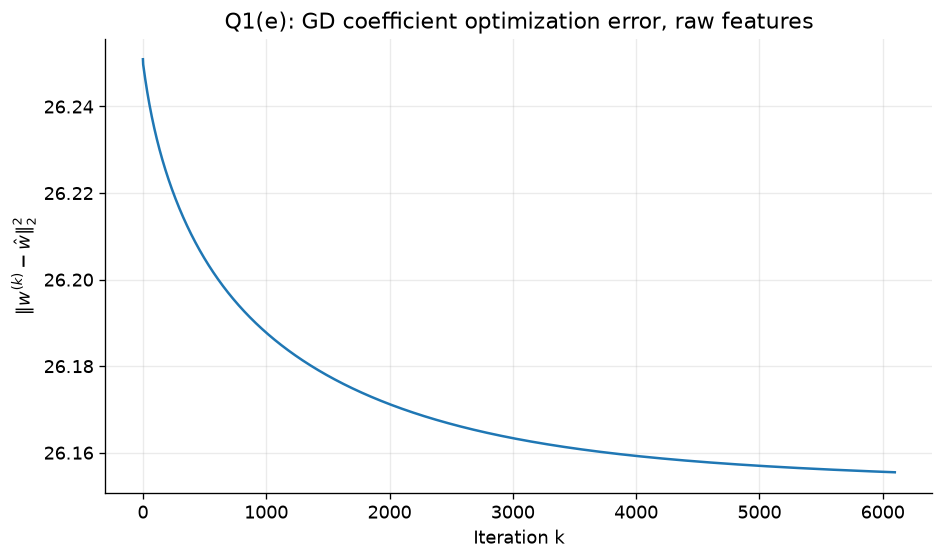

In [5]:
display(Markdown(r"""
With an intercept column in $A$, the gradient is
$$\nabla L(w)=\frac{1}{n}A^\top(Aw-y)=Hw-b,\qquad
H=\frac{A^\top A}{n},\quad b=\frac{A^\top y}{n}.$$
Thus $w^{(k+1)}=w^{(k)}-\eta(Hw^{(k)}-b)$.
The intercept is the **first** coefficient throughout Q1. Iteration 0 is the
zero initialization; all subsequent recorded quantities use the updated vector.
"""))
q1_A_train = np.column_stack([np.ones(len(q1_y_train)), q1_X_train])
q1_A_test = np.column_stack([np.ones(len(q1_y_test)), q1_X_test])
q1_H = q1_A_train.T @ q1_A_train / len(q1_y_train)
q1_b = q1_A_train.T @ q1_y_train / len(q1_y_train)

def q1_optimize(H, b, w_star, eta, *, method='GD', beta=0.9,
                max_iterations=100000, stopping='gradient', tol=1e-5,
                A_test=None, y_test=None):
    w = np.zeros_like(b)
    previous = w.copy()  # w^(-1) = w^(0) = 0
    errors = [np.sum((w - w_star) ** 2)]
    gradients = [np.linalg.norm(H @ w - b)]
    test_mses = ([np.mean((y_test - A_test @ w) ** 2)]
                 if A_test is not None else [])
    status = 'iteration limit reached'
    step_norm = np.nan
    for k in range(1, max_iterations + 1):
        if method == 'GD':
            w_new = w - eta * (H @ w - b)
        elif method == 'Polyak':
            w_new = w + beta * (w - previous) - eta * (H @ w - b)
        elif method == 'Nesterov':
            lookahead = w + beta * (w - previous)
            w_new = lookahead - eta * (H @ lookahead - b)
        else:
            raise ValueError(method)
        step_norm = np.linalg.norm(w_new - w)
        previous, w = w, w_new
        errors.append(np.sum((w - w_star) ** 2))
        gradients.append(np.linalg.norm(H @ w - b))
        if A_test is not None:
            test_mses.append(np.mean((y_test - A_test @ w) ** 2))
        # Protect against numerical overflow in the deliberately unstable run.
        if not np.isfinite(w).all() or np.max(np.abs(w)) > 1e100:
            status = 'diverged (large-norm guard)'
            break
        stop_value = step_norm if stopping == 'step' else gradients[-1]
        if stop_value < tol:
            status = f'{stopping} tolerance reached'
            break
    return {'w': w, 'iterations': k, 'status': status,
            'step_norm': step_norm, 'opt_error': np.asarray(errors),
            'grad_norm': np.asarray(gradients), 'test_mse': np.asarray(test_mses)}

q1_gd_raw = q1_optimize(q1_H, q1_b, q1_w_star, 6e-7,
                         max_iterations=100000, stopping='step',
                         A_test=q1_A_test, y_test=q1_y_test)
print(f"Iterations: {q1_gd_raw['iterations']:,}; {q1_gd_raw['status']}")
print(f"Final step norm: {q1_gd_raw['step_norm']:.9g}")
print(f"Final gradient norm: {q1_gd_raw['grad_norm'][-1]:.9g}")
print(f"Final coefficient optimization error: {q1_gd_raw['opt_error'][-1]:.6f}")
plt.figure()
plt.plot(np.arange(len(q1_gd_raw['opt_error'])), q1_gd_raw['opt_error'])
plt.xlabel('Iteration k')
plt.ylabel(r'$\|w^{(k)}-\hat w\|_2^2$')
plt.title('Q1(e): GD coefficient optimization error, raw features')
plt.tight_layout()
plt.show()

#### f) Please plot the testing MSE vs iteration.

Final GD testing MSE: 131.735804
OLS testing MSE: 130.571625
Lowest observed testing MSE: 131.735804 at iteration 6,098 (descriptive only)


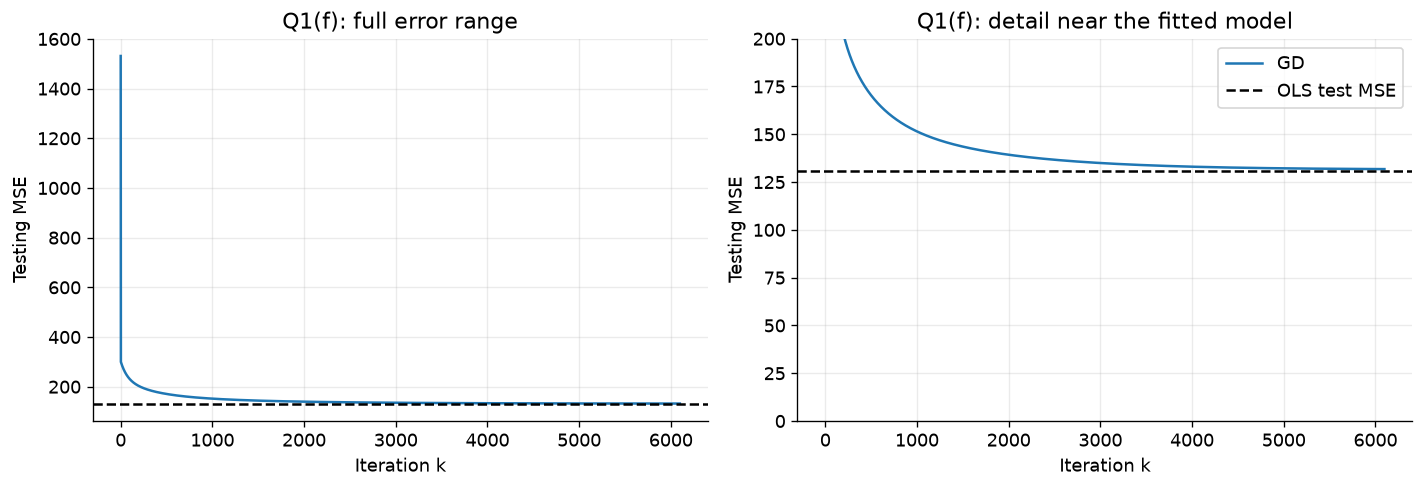

In [6]:
q1_iter_raw = np.arange(len(q1_gd_raw['test_mse']))
q1_observed_best = int(np.argmin(q1_gd_raw['test_mse']))
print(f"Final GD testing MSE: {q1_gd_raw['test_mse'][-1]:.6f}")
print(f'OLS testing MSE: {q1_test_mse:.6f}')
print(f'Lowest observed testing MSE: {q1_gd_raw["test_mse"][q1_observed_best]:.6f} '
      f'at iteration {q1_observed_best:,} (descriptive only)')
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax in axes:
    ax.plot(q1_iter_raw, q1_gd_raw['test_mse'], label='GD')
    ax.axhline(q1_test_mse, color='black', ls='--', label='OLS test MSE')
    ax.set_xlabel('Iteration k')
    ax.set_ylabel('Testing MSE')
axes[0].set_title('Q1(f): full error range')
axes[1].set_ylim(0, max(200, 1.4 * q1_test_mse))
axes[1].set_title('Q1(f): detail near the fitted model')
axes[1].legend()
fig.tight_layout()
plt.show()

#### g) Given what you have observed in e) and f), what can you say about the number of iterations we need from a prediction perspective? Why?

In [7]:
q1_first_near = np.flatnonzero(q1_gd_raw['test_mse'] <= 1.01 * q1_test_mse)
q1_near_text = (f'The first iterate within 1% above the OLS test MSE is '
                f'k = {q1_first_near[0]:,}.' if len(q1_first_near)
                else 'No recorded iterate gets within 1% above the OLS test MSE.')
display(Markdown(
    q1_near_text + ' Prediction quality can stabilize long before the coefficient '
    'vector is close to its OLS value. On an ill-conditioned design, large changes '
    'along low-curvature coefficient directions produce only small changes in '
    'predictions, whereas the high-curvature directions are learned quickly. '
    f'At termination, squared coefficient error is '
    f'{q1_gd_raw["opt_error"][-1]:.6f} and test MSE is '
    f'{q1_gd_raw["test_mse"][-1]:.6f}. '
    'The step-norm tolerance in (e) is also scaled by the very small stepsize, '
    'so a small update need not mean a small gradient. From a prediction '
    'perspective, use a validation set to choose an early stopping point; the '
    'test curve here is for the requested analysis and should not be used to '
    'tune a deployed model.'))

The first iterate within 1% above the OLS test MSE is k = 5,579. Prediction quality can stabilize long before the coefficient vector is close to its OLS value. On an ill-conditioned design, large changes along low-curvature coefficient directions produce only small changes in predictions, whereas the high-curvature directions are learned quickly. At termination, squared coefficient error is 26.155452 and test MSE is 131.735804. The step-norm tolerance in (e) is also scaled by the very small stepsize, so a small update need not mean a small gradient. From a prediction perspective, use a validation set to choose an early stopping point; the test curve here is for the requested analysis and should not be used to tune a deployed model.

#### h) In e) the stepsize was given to you. Now derive the largest stepsize for which gradient descent converges.

Recall from the lecture that a fixed stepsize $\eta$ converges only if
<center>$\eta < 2/\lambda_{\max}\left(\frac{1}{n}X^\top X\right)$.</center>

Compute $\lambda_{\max}\left(\frac{1}{n}X^\top X\right)$ for the training set of Q1 (remember to include the intercept column) and report this bound. Then run gradient descent with stepsize equal to $0.5\times$, $1.0\times$ and $2.0\times$ the bound, and report what happens in each case. *Hint:* `numpy.linalg.eigvalsh`.


For $e_k=w^{(k)}-\hat w$, $e_{k+1}=(I-\eta H)e_k$.
In eigendirection $i$, the error is multiplied by $1-\eta\lambda_i$.
Because this design has full column rank, convergence from arbitrary initial
values requires $|1-\eta\lambda_i|<1$ for every $i$, equivalently
$0<\eta<2/\lambda_{\max}(H)$. The upper bound is a **supremum**, not an
admissible largest stepsize: equality generally produces an oscillation.


lambda_min(H) = 0.000141307144559
lambda_max(H) = 1672866.88695
Strict upper stepsize bound = 1.19555238711e-06


,bound multiplier,stepsize,iterations,status,final grad norm,final Opt. Err.,largest-mode multiplier
0,0.500000,5.97776194e-07,100000,iteration limit reached,1.12686,26.1295,0.0
1,1.000000,1.19555239e-06,100000,iteration limit reached,46402.3,26.1244,-1.0
2,2.000000,2.39110477e-06,214,diverged (large-norm guard),5.89506e+106,1.24181e+201,-3.0


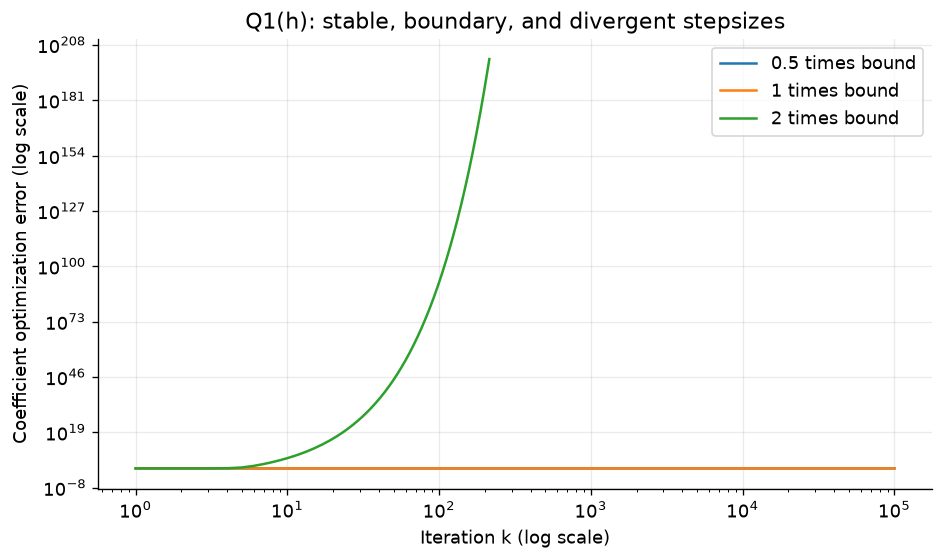

**0.5 times the bound:** convergent in theory, but very slow in the smallest-eigenvalue direction; the gradient tolerance is not reached within 100,000 updates. **1.0 times the bound:** the largest-eigenvalue component has multiplier -1, so it alternates without decaying. **2.0 times the bound:** that multiplier is -3, so the iterates diverge. The unstable experiment stops at a large-norm guard to avoid overflow. All runs start at zero, and (h) uses the gradient-norm tolerance needed for a direct comparison with (i), rather than the update tolerance of (e).

In [8]:
q1_eigenvalues = np.linalg.eigvalsh(q1_H)
q1_raw_bound = 2 / q1_eigenvalues[-1]
display(Markdown(r"""
For $e_k=w^{(k)}-\hat w$, $e_{k+1}=(I-\eta H)e_k$.
In eigendirection $i$, the error is multiplied by $1-\eta\lambda_i$.
Because this design has full column rank, convergence from arbitrary initial
values requires $|1-\eta\lambda_i|<1$ for every $i$, equivalently
$0<\eta<2/\lambda_{\max}(H)$. The upper bound is a **supremum**, not an
admissible largest stepsize: equality generally produces an oscillation.
"""))
print(f'lambda_min(H) = {q1_eigenvalues[0]:.12g}')
print(f'lambda_max(H) = {q1_eigenvalues[-1]:.12g}')
print(f'Strict upper stepsize bound = {q1_raw_bound:.12g}')
q1_h_runs = {}
q1_h_rows = []
for factor in [0.5, 1.0, 2.0]:
    eta = factor * q1_raw_bound
    run = q1_optimize(q1_H, q1_b, q1_w_star, eta,
                      max_iterations=100000, stopping='gradient')
    q1_h_runs[factor] = run
    q1_h_rows.append({'bound multiplier': factor, 'stepsize': eta,
                      'iterations': run['iterations'], 'status': run['status'],
                      'final grad norm': run['grad_norm'][-1],
                      'final Opt. Err.': run['opt_error'][-1],
                      'largest-mode multiplier': 1-eta*q1_eigenvalues[-1]})
display(pd.DataFrame(q1_h_rows).style.format({
    'stepsize': '{:.9g}', 'final grad norm': '{:.6g}',
    'final Opt. Err.': '{:.6g}', 'largest-mode multiplier': '{:.1f}'}))
fig, ax = plt.subplots(figsize=(8, 4.8))
for factor, run in q1_h_runs.items():
    ax.loglog(np.arange(1, len(run['opt_error'])), run['opt_error'][1:],
              label=f'{factor:g} times bound')
ax.set_xlabel('Iteration k (log scale)')
ax.set_ylabel('Coefficient optimization error (log scale)')
ax.set_title('Q1(h): stable, boundary, and divergent stepsizes')
ax.legend()
fig.tight_layout()
plt.show()
display(Markdown(
    '**0.5 times the bound:** convergent in theory, but very slow in the '
    'smallest-eigenvalue direction; the gradient tolerance is not reached '
    'within 100,000 updates. **1.0 times the bound:** the largest-eigenvalue '
    'component has multiplier -1, so it alternates without decaying. '
    '**2.0 times the bound:** that multiplier is -3, so the iterates diverge. '
    'The unstable experiment stops at a large-norm guard to avoid overflow. '
    'All runs start at zero, and (h) uses the gradient-norm tolerance needed '
    'for a direct comparison with (i), rather than the update tolerance of (e).'))

#### i) Standardize the training set, and standardize the testing set using the statistics of the training set. Then:

* Refit OLS on the standardized training set and report the training and testing MSE. Compare with a) and b).
* Report the condition number of $X^\top X$ before and after standardization, and the new stepsize bound.
* Rerun gradient descent on the standardized problem with stepsize equal to half the new bound, and report how many iterations it now takes to reach $\|\nabla L(w^{(k)})\|_2 < 10^{-5}$. Compare with h).

**Note:** the OLS coefficient vector on standardized features is not the same as the one from a). When you compute Opt. Err. here, use the OLS coefficients refit on the *standardized* training set, otherwise $\hat{w}$ and $w^{(k)}$ are in different units.

In [9]:
q1_scaler = StandardScaler().fit(q1_X_train)
q1_Xs_train = q1_scaler.transform(q1_X_train)
q1_Xs_test = q1_scaler.transform(q1_X_test)
q1_ols_std = LinearRegression().fit(q1_Xs_train, q1_y_train)
q1_ws_star = np.r_[q1_ols_std.intercept_, q1_ols_std.coef_]
q1_std_train_mse = mean_squared_error(q1_y_train, q1_ols_std.predict(q1_Xs_train))
q1_std_test_mse = mean_squared_error(q1_y_test, q1_ols_std.predict(q1_Xs_test))
q1_As_train = np.column_stack([np.ones(len(q1_y_train)), q1_Xs_train])
q1_As_test = np.column_stack([np.ones(len(q1_y_test)), q1_Xs_test])
q1_Hs = q1_As_train.T @ q1_As_train / len(q1_y_train)
q1_bs = q1_As_train.T @ q1_y_train / len(q1_y_train)
q1_eigs_std = np.linalg.eigvalsh(q1_Hs)
q1_std_bound = 2 / q1_eigs_std[-1]
q1_eta_std = 0.5 * q1_std_bound
q1_cond_raw = np.linalg.cond(q1_A_train.T @ q1_A_train)
q1_cond_std = np.linalg.cond(q1_As_train.T @ q1_As_train)
display(pd.DataFrame([
    {'features': 'raw', 'training MSE': q1_train_mse, 'testing MSE': q1_test_mse,
     'cond(A.T @ A)': q1_cond_raw, 'strict stepsize bound': q1_raw_bound},
    {'features': 'standardized', 'training MSE': q1_std_train_mse,
     'testing MSE': q1_std_test_mse, 'cond(A.T @ A)': q1_cond_std,
     'strict stepsize bound': q1_std_bound}]).style.format({
         'training MSE': '{:.6f}', 'testing MSE': '{:.6f}',
         'cond(A.T @ A)': '{:.9g}', 'strict stepsize bound': '{:.9g}'}))
q1_gd_std = q1_optimize(q1_Hs, q1_bs, q1_ws_star, q1_eta_std,
                         stopping='gradient', A_test=q1_As_test, y_test=q1_y_test)
print(f'Standardized stepsize = {q1_eta_std:.12g}')
print(f"Standardized GD iterations = {q1_gd_std['iterations']}; "
      f"final gradient norm = {q1_gd_std['grad_norm'][-1]:.9g}")
print(f"Raw GD at half its bound: {q1_h_runs[0.5]['iterations']:,} iterations, "
      f"final gradient norm = {q1_h_runs[0.5]['grad_norm'][-1]:.9g}")
display(Markdown(
    'The OLS MSEs agree up to floating-point rounding: invertible centering and '
    'rescaling preserve the set of affine prediction functions. The intercept '
    'column remains 1 and is included in both reported condition numbers. '
    'Standardization substantially improves conditioning and allows a much '
    'larger stable stepsize. The gradient tolerance uses the coordinates of each '
    'problem, so gradient norms themselves are not invariant to rescaling. '
    'All standardized optimization errors below use the refitted standardized '
    'OLS coefficients.'))

,features,training MSE,testing MSE,cond(A.T @ A),strict stepsize bound
0,raw,101.065094,130.571625,1.18385159e+10,1.19555239e-06
1,standardized,101.065094,130.571625,80.3353923,0.868847575


Standardized stepsize = 0.43442378765
Standardized GD iterations = 821; final gradient norm = 9.89715526e-06
Raw GD at half its bound: 100,000 iterations, final gradient norm = 1.12686087


The OLS MSEs agree up to floating-point rounding: invertible centering and rescaling preserve the set of affine prediction functions. The intercept column remains 1 and is included in both reported condition numbers. Standardization substantially improves conditioning and allows a much larger stable stepsize. The gradient tolerance uses the coordinates of each problem, so gradient norms themselves are not invariant to rescaling. All standardized optimization errors below use the refitted standardized OLS coefficients.

#### j) Implement Polyak's momentum (heavy ball) and Nesterov's momentum on the standardized problem of i):

<center>Polyak: $w^{(k+1)} = w^{(k)} + \beta(w^{(k)} - w^{(k-1)}) - \eta\nabla L(w^{(k)})$</center>

<center>Nesterov: $w^{(k+1)} = w^{(k)} + \beta(w^{(k)} - w^{(k-1)}) - \eta\nabla L\big(w^{(k)} + \beta(w^{(k)} - w^{(k-1)})\big)$</center>

Initialize $w^{(0)} = w^{(-1)} = 0$. Use the same stepsize as in i) and set $\beta = 0.9$. Plot Opt. Err. vs iteration for gradient descent, Polyak's momentum and Nesterov's momentum on the same figure (use a logarithmic scale for Opt. Err.), and report the number of iterations each one needs to reach $\|\nabla L(w^{(k)})\|_2 < 10^{-5}$.

,method,iterations,final gradient norm,final Opt. Err.,status
0,GD,821,0.000010,1.193059e-07,gradient tolerance reached
1,Polyak,267,0.000009,8.328871e-11,gradient tolerance reached
2,Nesterov,147,0.000007,5.693341e-08,gradient tolerance reached


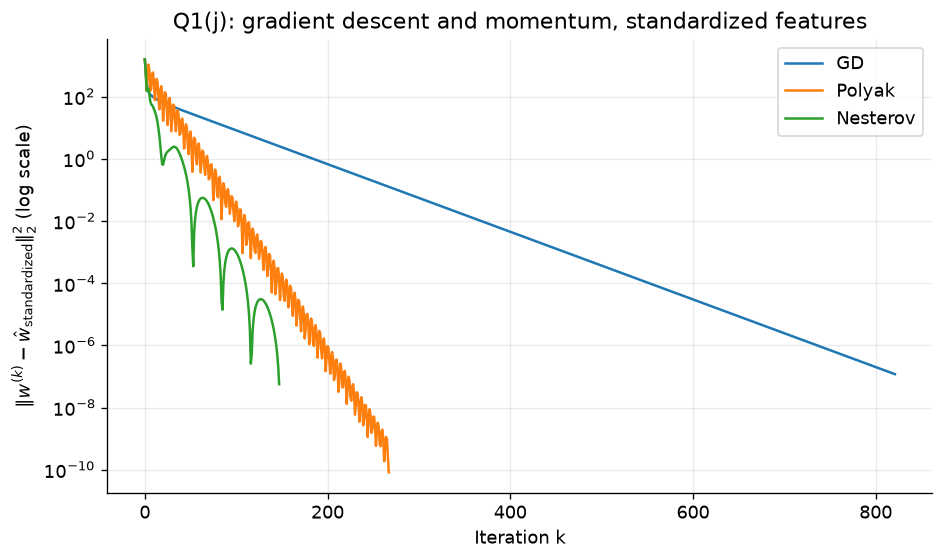

In [10]:
q1_momentum_runs = {'GD': q1_gd_std}
for method in ['Polyak', 'Nesterov']:
    q1_momentum_runs[method] = q1_optimize(
        q1_Hs, q1_bs, q1_ws_star, q1_eta_std,
        method=method, beta=0.9, stopping='gradient')
q1_momentum_table = pd.DataFrame([
    {'method': method, 'iterations': run['iterations'],
     'final gradient norm': run['grad_norm'][-1],
     'final Opt. Err.': run['opt_error'][-1], 'status': run['status']}
    for method, run in q1_momentum_runs.items()])
display(q1_momentum_table)
fig, ax = plt.subplots(figsize=(8, 4.8))
for method, run in q1_momentum_runs.items():
    ax.semilogy(np.arange(len(run['opt_error'])), run['opt_error'], label=method)
ax.set_xlabel('Iteration k')
ax.set_ylabel(r'$\|w^{(k)}-\hat w_{\rm standardized}\|_2^2$ (log scale)')
ax.set_title('Q1(j): gradient descent and momentum, standardized features')
ax.legend()
fig.tight_layout()
plt.show()

#### k) Which method converged fastest? Why does momentum help here, and what property of $\frac{1}{n}X^\top X$ decides how much it helps?

In [11]:
q1_fastest = min(q1_momentum_runs, key=lambda name: q1_momentum_runs[name]['iterations'])
display(Markdown(
    f'**{q1_fastest} converged fastest**, taking '
    f'{q1_momentum_runs[q1_fastest]["iterations"]} updates to meet the common '
    f'gradient tolerance. The standardized Hessian has eigenvalues from '
    f'{q1_eigs_std[0]:.6f} to {q1_eigs_std[-1]:.6f}, giving condition number '
    f'{q1_cond_std:.6f}. Ordinary GD uses a stepsize limited by the largest '
    'eigenvalue and therefore moves slowly along directions with small eigenvalues. '
    'Momentum accumulates movement in those persistent directions, although it can '
    'overshoot and produce oscillatory coefficient errors. Nesterov evaluates the '
    'gradient at the lookahead point, which changes the damping of those oscillations. '
    'The Hessian eigenvalue spectrum, especially its condition number '
    r'$\kappa=\lambda_{\max}/\lambda_{\min}$, determines the potential speedup. '
    'With optimally chosen parameters, acceleration can improve the dependence '
    'on conditioning from order kappa to order square root of kappa. The fixed '
    'beta = 0.9 used here is not an optimal tuning guarantee for every dataset.'))

**Nesterov converged fastest**, taking 147 updates to meet the common gradient tolerance. The standardized Hessian has eigenvalues from 0.028654 to 2.301900, giving condition number 80.335392. Ordinary GD uses a stepsize limited by the largest eigenvalue and therefore moves slowly along directions with small eigenvalues. Momentum accumulates movement in those persistent directions, although it can overshoot and produce oscillatory coefficient errors. Nesterov evaluates the gradient at the lookahead point, which changes the damping of those oscillations. The Hessian eigenvalue spectrum, especially its condition number $\kappa=\lambda_{\max}/\lambda_{\min}$, determines the potential speedup. With optimally chosen parameters, acceleration can improve the dependence on conditioning from order kappa to order square root of kappa. The fixed beta = 0.9 used here is not an optimal tuning guarantee for every dataset.

### 2. Robust Regression

* The Concrete dataset for Q2 is in `Q2_train.xls` and `Q2_test.xls`.
* This dataset is very similar to that of Q1, but the training set is contaminated.
* Please refer to the following package for quantile regression:
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.QuantileRegressor.html
* Note that the quantile regression is identical to LAD regression when using 50% quantile. 

#### a) Train a linear regression model on the training dataset using OLS, and report the testing MSE.

In [12]:
from sklearn.linear_model import LinearRegression, QuantileRegressor, HuberRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

q2_X_train, q2_y_train, q2_feature_names = load_xy("Q2_train.xls")
q2_X_test, q2_y_test, _ = load_xy("Q2_test.xls")
q2_ols = LinearRegression().fit(q2_X_train, q2_y_train)
q2_ols_mse = mean_squared_error(q2_y_test, q2_ols.predict(q2_X_test))
print(f"Q2 data: {len(q2_y_train)} training and {len(q2_y_test)} testing samples")
print(f"OLS testing MSE: {q2_ols_mse:.6f}")


Q2 data: 800 training and 230 testing samples
OLS testing MSE: 173.657334


#### b) Train a linear regression model on the training dataset using LAD (set regularization constant alpha =1), and report the testing MSE.

In [13]:
# At the 0.5 quantile, pinball loss is half the absolute residual.
# Use the requested alpha=1 on the original feature units.
q2_lad = QuantileRegressor(quantile=0.5, alpha=1.0, solver="highs")
q2_lad.fit(q2_X_train, q2_y_train)
q2_lad_mse = mean_squared_error(q2_y_test, q2_lad.predict(q2_X_test))
print(f"LAD (alpha=1) testing MSE: {q2_lad_mse:.6f}")


LAD (alpha=1) testing MSE: 137.739939


#### c) Does LAD outperform OLS? Why?

In [14]:
display(Markdown(
    f"**Yes.** LAD has testing MSE **{q2_lad_mse:.6f}**, below OLS's "
    f"**{q2_ols_mse:.6f}**. The training data are contaminated: OLS squares "
    "residuals, so a few unusually large residuals can pull its fitted line strongly. "
    "Absolute loss grows only linearly, which reduces this sensitivity and gives "
    "better predictions on the test set here. The requested LAD fit also has an "
    "L1 coefficient penalty (alpha=1), so the comparison reflects both a robust "
    "loss and regularization. LAD is not guaranteed to beat OLS on every dataset, "
    "especially under clean Gaussian errors."
))


**Yes.** LAD has testing MSE **137.739939**, below OLS's **173.657334**. The training data are contaminated: OLS squares residuals, so a few unusually large residuals can pull its fitted line strongly. Absolute loss grows only linearly, which reduces this sensitivity and gives better predictions on the test set here. The requested LAD fit also has an L1 coefficient penalty (alpha=1), so the comparison reflects both a robust loss and regularization. LAD is not guaranteed to beat OLS on every dataset, especially under clean Gaussian errors.

#### d) Huber regression is a third robust alternative. Its loss is quadratic for small residuals and linear for large ones, with the crossover at $\epsilon$:

<center>$\ell_\epsilon(r) = \begin{cases} \frac{1}{2}r^2 & |r| \le \epsilon \\ \epsilon|r| - \frac{1}{2}\epsilon^2 & |r| > \epsilon\end{cases}$</center>

`HuberRegressor` does not converge on the raw features, so first standardize the training set and standardize the testing set using the training statistics. Report the testing MSE of OLS on the standardized features (it should match a)), then train Huber regression with `epsilon` $\in \{1.1, 1.35, 2.0, 5.0\}$ and `alpha=0.0` and report the testing MSE of each. Also report how many training points each fit treats as outliers (`.outliers_`).

Please refer to the following package for Huber regression:
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.HuberRegressor.html

In [15]:
# Fit the scaler only on training features; never use test-set statistics.
q2_scaler = StandardScaler()
q2_Z_train = q2_scaler.fit_transform(q2_X_train)
q2_Z_test = q2_scaler.transform(q2_X_test)
q2_ols_scaled = LinearRegression().fit(q2_Z_train, q2_y_train)
q2_ols_scaled_mse = mean_squared_error(q2_y_test, q2_ols_scaled.predict(q2_Z_test))
assert np.isclose(q2_ols_scaled_mse, q2_ols_mse, rtol=1e-10)
print(f"Standardized OLS testing MSE: {q2_ols_scaled_mse:.6f}")
print(f"Difference from raw-feature OLS: {q2_ols_scaled_mse - q2_ols_mse:.3e}")

q2_huber_fits = {}
q2_huber_rows = []
for q2_epsilon in [1.1, 1.35, 2.0, 5.0]:
    q2_fit = HuberRegressor(epsilon=q2_epsilon, alpha=0.0,
                            max_iter=2000, tol=1e-9)
    q2_fit.fit(q2_Z_train, q2_y_train)
    q2_huber_fits[q2_epsilon] = q2_fit
    q2_huber_rows.append({
        "epsilon": q2_epsilon,
        "testing MSE": mean_squared_error(q2_y_test, q2_fit.predict(q2_Z_test)),
        "training outliers": int(q2_fit.outliers_.sum()),
        "iterations": int(q2_fit.n_iter_),
        "estimated residual scale": q2_fit.scale_,
    })
q2_huber_results = pd.DataFrame(q2_huber_rows)
display(q2_huber_results.round(6))
display(Markdown(
    "In scikit-learn, epsilon applies to the residual divided by an estimated "
    r"scale, so an outlier satisfies $|y_i-\hat y_i| > \epsilon\hat\sigma$. "
    "These flags identify large fitted residuals, not known contamination labels. "
    "As epsilon changes, both the fit and the estimated scale change. "
    "See the [HuberRegressor documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.HuberRegressor.html)."
))


Standardized OLS testing MSE: 173.657334
Difference from raw-feature OLS: 0.000e+00


,epsilon,testing MSE,training outliers,iterations,estimated residual scale
0,1.10,149.738211,599,22,2.676812
1,1.35,143.891748,294,17,6.954945
2,2.00,150.195453,98,20,12.377708
3,5.00,173.655864,0,21,18.075827


In scikit-learn, epsilon applies to the residual divided by an estimated scale, so an outlier satisfies $|y_i-\hat y_i| > \epsilon\hat\sigma$. These flags identify large fitted residuals, not known contamination labels. As epsilon changes, both the fit and the estimated scale change. See the [HuberRegressor documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.HuberRegressor.html).

#### e) Rank OLS, LAD and the best Huber fit by testing MSE. Where does Huber sit relative to the other two, and why? What happens to Huber as $\epsilon$ grows large, and does your table confirm it?

In [16]:
q2_best_huber = q2_huber_results.loc[q2_huber_results["testing MSE"].idxmin()]
q2_ranking = pd.DataFrame([
    {"model": "OLS", "testing MSE": q2_ols_mse},
    {"model": "LAD (alpha=1)", "testing MSE": q2_lad_mse},
    {"model": f"Huber (epsilon={q2_best_huber['epsilon']:g})",
     "testing MSE": q2_best_huber["testing MSE"]},
]).sort_values("testing MSE", ignore_index=True)
display(q2_ranking.round(6))
display(Markdown(
    f"The ranking above is from lowest to highest testing MSE. The best Huber "
    f"fit among the requested values uses **epsilon={q2_best_huber['epsilon']:g}**. "
    "Here **LAD < best Huber < OLS** in testing MSE: the best Huber model "
    "improves on OLS but does not match LAD. Huber retains a quadratic loss "
    "for ordinary residuals while limiting the "
    "effect of large residuals; it can therefore combine OLS's efficiency near "
    "the center with resistance to contamination. Its exact position relative "
    "to LAD is data-dependent, and LAD also uses a different penalty here. "
    "When epsilon becomes large, fewer observations enter the linear-loss "
    "region and Huber approaches unregularized OLS. The table confirms this: "
    "at epsilon=5 there are zero flagged outliers and the testing MSE is "
    "173.655864, almost identical to OLS's 173.657334 (the small difference "
    "is numerical optimization tolerance). The change is not strictly "
    "monotone at small epsilon: 1.35 works better than 1.1 here. This is a descriptive "
    "test-set comparison requested by the problem; for deployment, epsilon "
    "would be selected on validation data rather than this test set."
))


,model,testing MSE
0,LAD (alpha=1),137.739939
1,Huber (epsilon=1.35),143.891748
2,OLS,173.657334


The ranking above is from lowest to highest testing MSE. The best Huber fit among the requested values uses **epsilon=1.35**. Here **LAD < best Huber < OLS** in testing MSE: the best Huber model improves on OLS but does not match LAD. Huber retains a quadratic loss for ordinary residuals while limiting the effect of large residuals; it can therefore combine OLS's efficiency near the center with resistance to contamination. Its exact position relative to LAD is data-dependent, and LAD also uses a different penalty here. When epsilon becomes large, fewer observations enter the linear-loss region and Huber approaches unregularized OLS. The table confirms this: at epsilon=5 there are zero flagged outliers and the testing MSE is 173.655864, almost identical to OLS's 173.657334 (the small difference is numerical optimization tolerance). The change is not strictly monotone at small epsilon: 1.35 works better than 1.1 here. This is a descriptive test-set comparison requested by the problem; for deployment, epsilon would be selected on validation data rather than this test set.

#### f) Tukey's biweight loss is bounded: it grows for small residuals and then flattens out completely, so points far enough from the fit have *zero* influence. This makes it more robust than Huber, but the loss is no longer convex. What does the nonconvexity cost you? Answer in terms of the trade-off between statistical and computational properties.

Tukey's loss is bounded and has a **redescending score**: its derivative returns to zero for sufficiently large residuals. Thus an extreme residual can have essentially no effect on the fit, improving resistance to response contamination when the inlier model and tuning constant are appropriate. This robustness is not automatic protection against arbitrary high-leverage feature outliers, and aggressive rejection may discard valid observations and reduce efficiency on clean data.

The computational cost is **nonconvex optimization**. There may be several local minima and flat regions, so an iterative algorithm can depend strongly on its initialization and converge to a poor solution. Unlike the convex LAD and Huber objectives, a local optimum need not be global. Robust initialization, multiple starts, and careful tuning can help, but require extra computation and do not generally certify the global optimum. The trade-off is stronger potential statistical robustness at the cost of a less stable and less easily guaranteed fitting procedure.


### 3. Linear Classification

* In this question, we use a dataset about spam emails (`Q3_train.csv` and `Q3_test.csv`) to study linear classifiers. For both training and testing data, the first 57 columns are different features of emails, such as the frequency of occurrence of a particular word, and the last column shows whether an email is spam (1 for spam). We will train linear classifiers to predict if a given email is spam.
* Please refer to the following package for different linear classifiers.\

Linear Discriminant Analysis Classifier:
https://scikit-learn.org/stable/modules/generated/sklearn.discriminant_analysis.LinearDiscriminantAnalysis.html

Gaussian Naive Bayes Classifier:
https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html

Logistic Regression Classifier:
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

* For this classification problem, we use classification error as the metric to evaluate the performance of trained models. Given $n$ samples, let $\{Y_i\}_{i=1}^n$ be the observed labels of the variable being predicted and $\{\hat{Y}_i\}_{i=1}^n$ be the predicted labels. Then the classification error of the predictor is computed as
<center>$\text{Classification Error} = \frac{1}{n} \sum_{i=1}^n \mathbb{1}(Y_i \neq \hat{Y}_i).$</center>


#### a) Train a Linear Discriminant Analysis Classifier using the training set and report the classification error on the testing set.

In [17]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

q3_X_train, q3_y_train, q3_feature_names = load_xy("Q3_train.csv")
q3_X_test, q3_y_test, _ = load_xy("Q3_test.csv")
q3_y_train = q3_y_train.astype(int)
q3_y_test = q3_y_test.astype(int)
q3_n, q3_d = q3_X_train.shape
assert q3_d == 57
q3_lda = LinearDiscriminantAnalysis().fit(q3_X_train, q3_y_train)
q3_lda_pred = q3_lda.predict(q3_X_test)
q3_lda_error = np.mean(q3_lda_pred != q3_y_test)
print(f"Q3 data: {q3_n} training, {len(q3_y_test)} testing samples; d={q3_d}")
print(f"LDA testing error: {q3_lda_error:.6f} ({q3_lda_error:.2%}); "
      f"{np.sum(q3_lda_pred != q3_y_test)} misclassified emails")


Q3 data: 2760 training, 1841 testing samples; d=57
LDA testing error: 0.099402 (9.94%); 183 misclassified emails


#### b) Repeat the above using Gaussian Naive Bayes Classifier.

In [18]:
q3_gnb = GaussianNB().fit(q3_X_train, q3_y_train)
q3_gnb_pred = q3_gnb.predict(q3_X_test)
q3_gnb_error = np.mean(q3_gnb_pred != q3_y_test)
print(f"Gaussian NB testing error: {q3_gnb_error:.6f} ({q3_gnb_error:.2%}); "
      f"{np.sum(q3_gnb_pred != q3_y_test)} misclassified emails")


Gaussian NB testing error: 0.191744 (19.17%); 353 misclassified emails


#### c) Repeat the above using Logistic Regression Classifier.

In [19]:
# Keep original units for part (g). newton-cholesky solves the same default
# L2-regularized objective (C=1) with an unpenalized intercept.
q3_logistic = LogisticRegression(C=1.0, solver="newton-cholesky",
                                 max_iter=1000, tol=1e-9)
q3_logistic.fit(q3_X_train, q3_y_train)
q3_lr_pred = q3_logistic.predict(q3_X_test)
q3_lr_error = np.mean(q3_lr_pred != q3_y_test)
print(f"Logistic regression testing error: {q3_lr_error:.6f} ({q3_lr_error:.2%}); "
      f"{np.sum(q3_lr_pred != q3_y_test)} misclassified emails")
print(f"Newton iterations: {q3_logistic.n_iter_[0]}")
q3_error_results = pd.DataFrame({
    "classifier": ["LDA", "Gaussian NB", "Logistic regression"],
    "testing classification error": [q3_lda_error, q3_gnb_error, q3_lr_error],
})
display(q3_error_results.round(6))


Logistic regression testing error: 0.074416 (7.44%); 137 misclassified emails
Newton iterations: 11


,classifier,testing classification error
0,LDA,0.099402
1,Gaussian NB,0.191744
2,Logistic regression,0.074416


#### d) Please compare the classification errors of Linear Discriminant Analysis and Gaussian Naive Bayes Classifier, and provide an explanation for the results.

In [20]:
display(Markdown(
    f"LDA's error is **{q3_lda_error:.2%}**, compared with **{q3_gnb_error:.2%}** "
    "for Gaussian NB. LDA estimates a full covariance shared by the two classes, "
    "so it can account for correlations between email features. Gaussian NB "
    "assumes conditional independence and ignores those within-class "
    "correlations; correlated word frequencies can then be counted as separate "
    "pieces of evidence. Both methods assume Gaussian class-conditional "
    "distributions, which need not fit sparse frequency features well. The "
    "observed gap is consistent with the independence restriction being costly "
    "here, but one test split does not prove the causal explanation. "
    "Although the question groups these methods under linear classification, "
    "scikit-learn's GaussianNB uses class-specific diagonal variances: its "
    "log-odds generally contain squared features, so its boundary need not be linear."
))


LDA's error is **9.94%**, compared with **19.17%** for Gaussian NB. LDA estimates a full covariance shared by the two classes, so it can account for correlations between email features. Gaussian NB assumes conditional independence and ignores those within-class correlations; correlated word frequencies can then be counted as separate pieces of evidence. Both methods assume Gaussian class-conditional distributions, which need not fit sparse frequency features well. The observed gap is consistent with the independence restriction being costly here, but one test split does not prove the causal explanation. Although the question groups these methods under linear classification, scikit-learn's GaussianNB uses class-specific diagonal variances: its log-odds generally contain squared features, so its boundary need not be linear.

#### e) Please compare the classification errors of Linear Discriminant Analysis and Logistic Regression, and provide an explanation for the results.

In [21]:
display(Markdown(
    f"Logistic regression has error **{q3_lr_error:.2%}**, below LDA's "
    f"**{q3_lda_error:.2%}** on this test set. Both have a linear decision "
    "boundary, but logistic regression models the conditional probability "
    r"$P(Y=1\mid X)$ directly. It does not require the class-conditional "
    "features to be Gaussian with equal covariance, which is helpful for "
    "skewed, sparse email frequencies. It also estimates fewer parameters "
    "and the fitted model uses L2 regularization, both of which can reduce "
    "estimation variability. These are plausible explanations, rather than "
    "a universal guarantee that logistic regression beats LDA. If LDA's "
    "distributional assumptions were correct, their generative structure "
    "could instead provide useful statistical efficiency."
))


Logistic regression has error **7.44%**, below LDA's **9.94%** on this test set. Both have a linear decision boundary, but logistic regression models the conditional probability $P(Y=1\mid X)$ directly. It does not require the class-conditional features to be Gaussian with equal covariance, which is helpful for skewed, sparse email frequencies. It also estimates fewer parameters and the fitted model uses L2 regularization, both of which can reduce estimation variability. These are plausible explanations, rather than a universal guarantee that logistic regression beats LDA. If LDA's distributional assumptions were correct, their generative structure could instead provide useful statistical efficiency.

#### f) Count the free parameters of the three classifiers you just trained, at the dimension $d$ of this dataset:

* Linear Discriminant Analysis: $1 + 2d + \frac{d(d+1)}{2}$
* Gaussian Naive Bayes with a shared covariance: $1 + 2d + d$
* Logistic Regression: $d + 1$

**Note:** `GaussianNB` in scikit-learn estimates a separate variance for each feature *and each class*, so the model you actually fitted in b) has $1 + 2d + 2d$ parameters rather than the shared-covariance count above. Report both.

Report each count and the ratio $n/p$ of training samples to parameters. Based on these numbers alone, which classifier would you expect to have the largest estimation variance? Is that consistent with the errors you measured in a), b) and c)?

In [22]:
q3_parameter_counts = {
    "LDA": 1 + 2*q3_d + q3_d*(q3_d + 1)//2,
    "Gaussian NB, shared diagonal covariance (hypothetical)": 1 + 2*q3_d + q3_d,
    "GaussianNB, class-specific diagonal variances (fitted)": 1 + 2*q3_d + 2*q3_d,
    "Logistic regression": q3_d + 1,
}
q3_parameter_table = pd.DataFrame([
    {"classifier": q3_name, "p": q3_p, "n/p": q3_n / q3_p}
    for q3_name, q3_p in q3_parameter_counts.items()
])
print(f"Training sample count n={q3_n}; feature dimension d={q3_d}")
display(q3_parameter_table.round(6))
display(Markdown(
    "The single prior parameter is $P(Y=1)$; the other prior is its complement. "
    "The Gaussian models have two class means, and their covariance assumptions "
    "determine the remaining counts. These are nominal free-parameter counts; "
    "the fixed variance-smoothing constant and fixed regularization strength "
    "are not additional fitted parameters.\n\n"
    "**Based on counts alone, LDA would be expected to have the largest "
    "estimation variance**, because it has the most parameters and the "
    "smallest n/p. This rough prediction is consistent with LDA losing to "
    "logistic regression, but not with LDA beating Gaussian NB if one "
    "incorrectly assumes that variance alone determines test error. "
    "Test error also includes model bias, irreducible error, regularization "
    "effects, and sampling noise. Furthermore, each observation contributes "
    "to many mean/covariance entries: n/p is only a heuristic, not an effective "
    "sample size or a direct estimate of classifier variance. Repeated "
    "training samples would be needed to measure estimation variance."
))


Training sample count n=2760; feature dimension d=57


,classifier,p,n/p
0,LDA,1768,1.561086
1,"Gaussian NB, shared diagonal covariance (hypot...",172,16.046512
2,"GaussianNB, class-specific diagonal variances ...",229,12.052402
3,Logistic regression,58,47.586207


The single prior parameter is $P(Y=1)$; the other prior is its complement. The Gaussian models have two class means, and their covariance assumptions determine the remaining counts. These are nominal free-parameter counts; the fixed variance-smoothing constant and fixed regularization strength are not additional fitted parameters.

**Based on counts alone, LDA would be expected to have the largest estimation variance**, because it has the most parameters and the smallest n/p. This rough prediction is consistent with LDA losing to logistic regression, but not with LDA beating Gaussian NB if one incorrectly assumes that variance alone determines test error. Test error also includes model bias, irreducible error, regularization effects, and sampling noise. Furthermore, each observation contributes to many mean/covariance entries: n/p is only a heuristic, not an effective sample size or a direct estimate of classifier variance. Repeated training samples would be needed to measure estimation variance.

#### g) For the logistic regression model of c), the coefficient $\theta_j$ is the change in the log odds of an email being spam per unit change in feature $j$, and $e^{\theta_j}$ is the corresponding odds ratio.

Report the 5 features with the largest $|\theta_j|$ together with their odds ratios. Interpret one feature with a positive coefficient and one with a negative coefficient. Finally, explain why a one-unit change in $x_j$ does *not* change the predicted probability by a constant amount, even though it changes the log odds by a constant $\theta_j$.

In [23]:
q3_theta = q3_logistic.coef_[0]
q3_top5 = np.argsort(np.abs(q3_theta))[::-1][:5]
q3_coefficient_table = pd.DataFrame({
    "feature": np.asarray(q3_feature_names)[q3_top5],
    "coefficient theta": q3_theta[q3_top5],
    "absolute coefficient": np.abs(q3_theta[q3_top5]),
    "odds ratio exp(theta)": np.exp(q3_theta[q3_top5]),
})
display(q3_coefficient_table.round(6))

q3_positive = int(np.argmax(q3_theta))
q3_negative = int(np.argmin(q3_theta))
display(Markdown(
    f"Holding every other feature fixed, increasing **{q3_feature_names[q3_positive]}** "
    f"by one unit in the stored data increases spam log odds by "
    f"**{q3_theta[q3_positive]:.6f}** and multiplies the odds by "
    f"**{np.exp(q3_theta[q3_positive]):.6f}**. Increasing "
    f"**{q3_feature_names[q3_negative]}** by one stored unit changes spam log "
    f"odds by **{q3_theta[q3_negative]:.6f}** and multiplies the odds by "
    f"**{np.exp(q3_theta[q3_negative]):.6f}**, a decrease. These are model "
    "associations conditional on the other features, not causal effects. "
    "The requested ranking uses coefficients in original feature units; "
    "because feature scales differ, it is not a scale-invariant ranking "
    "of predictive importance.\n\n"
    r"If the initial spam probability is $p$, a one-unit increase gives "
    r"$p'=\frac{e^{\theta_j}p}{1-p+e^{\theta_j}p}$. Thus $p'-p$ depends on "
    r"the starting probability, not just on $\theta_j$. Infinitesimally, "
    r"$\partial p/\partial x_j=\theta_jp(1-p)$: the sigmoid is nonlinear, "
    r"and changes are smaller near probabilities zero and one."
))


,feature,coefficient theta,absolute coefficient,odds ratio exp(theta)
0,word_freq_george,-3.405515,3.405515,0.033190
1,char_freq_%24,3.128006,3.128006,22.828414
2,word_freq_remove,2.308473,2.308473,10.059049
3,word_freq_000,1.975712,1.975712,7.211753
4,word_freq_hp,-1.827423,1.827423,0.160828


Holding every other feature fixed, increasing **char_freq_%24** by one unit in the stored data increases spam log odds by **3.128006** and multiplies the odds by **22.828414**. Increasing **word_freq_george** by one stored unit changes spam log odds by **-3.405515** and multiplies the odds by **0.033190**, a decrease. These are model associations conditional on the other features, not causal effects. The requested ranking uses coefficients in original feature units; because feature scales differ, it is not a scale-invariant ranking of predictive importance.

If the initial spam probability is $p$, a one-unit increase gives $p'=\frac{e^{\theta_j}p}{1-p+e^{\theta_j}p}$. Thus $p'-p$ depends on the starting probability, not just on $\theta_j$. Infinitesimally, $\partial p/\partial x_j=\theta_jp(1-p)$: the sigmoid is nonlinear, and changes are smaller near probabilities zero and one.

### 4. K Nearest Neighbor Classifier

* In this question, we use a dataset about diabetes (`Q4_train.csv` and `Q4_test.csv`) to study K Nearest Neighbor Classifier. For both training and testing data, the first 8 columns are different diagnostic measurements of patients, such as Blood Pressure and BMI, and the last column shows whether a patient has diabetes (1 for diabetes). We will train a K Nearest Neighbor Classifier to predict if a person has diabetes.
* Please refer to the following package for K Nearest Neighbor Classifier:
https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

#### a) Train a K Nearest Neighbor Classifier with Euclidean Distance (Try K=1,3,5,9,15) to fit the provided diabetes training set, and predict the responses of the testing set. Plot the classification error vs K.

Training observations: 513; testing observations: 254


,Distance,K,Test mistakes,Test error
0,euclidean,1,95,0.374016
1,euclidean,3,79,0.311024
2,euclidean,5,68,0.267717
3,euclidean,9,62,0.244094
4,euclidean,15,67,0.263780


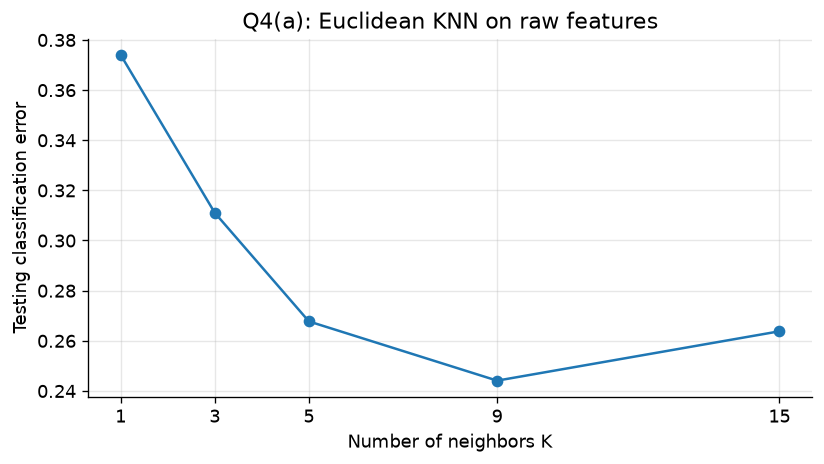

In [24]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

q4_X_train, q4_y_train, q4_feature_names = load_xy("Q4_train.csv")
q4_X_test, q4_y_test, _ = load_xy("Q4_test.csv")
q4_small_grid = [1, 3, 5, 9, 15]

def q4_knn_errors(X_train, y_train, X_test, y_test, grid, metric):
    """Uniform-vote KNN; every candidate is fitted on the training data only."""
    rows = []
    for k in grid:
        model = KNeighborsClassifier(n_neighbors=k, metric=metric, weights="uniform")
        model.fit(X_train, y_train)
        wrong = int(np.count_nonzero(model.predict(X_test) != y_test))
        rows.append({"Distance": metric, "K": k, "Test mistakes": wrong,
                     "Test error": wrong / len(y_test)})
    return pd.DataFrame(rows)

q4_raw_euclidean = q4_knn_errors(
    q4_X_train, q4_y_train, q4_X_test, q4_y_test, q4_small_grid, "euclidean"
)
print(f"Training observations: {len(q4_y_train)}; testing observations: {len(q4_y_test)}")
display(q4_raw_euclidean.round(6))
plt.figure(figsize=(7, 4))
plt.plot(q4_raw_euclidean["K"], q4_raw_euclidean["Test error"], "o-", color="tab:blue")
plt.xticks(q4_small_grid)
plt.xlabel("Number of neighbors K")
plt.ylabel("Testing classification error")
plt.title("Q4(a): Euclidean KNN on raw features")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


#### b) Repeat the above using a K Nearest Neighbor Classifier with Manhattan Distance ($L_1$-distance).

,Distance,K,Test mistakes,Test error
0,manhattan,1,89,0.350394
1,manhattan,3,86,0.338583
2,manhattan,5,69,0.271654
3,manhattan,9,67,0.263780
4,manhattan,15,65,0.255906


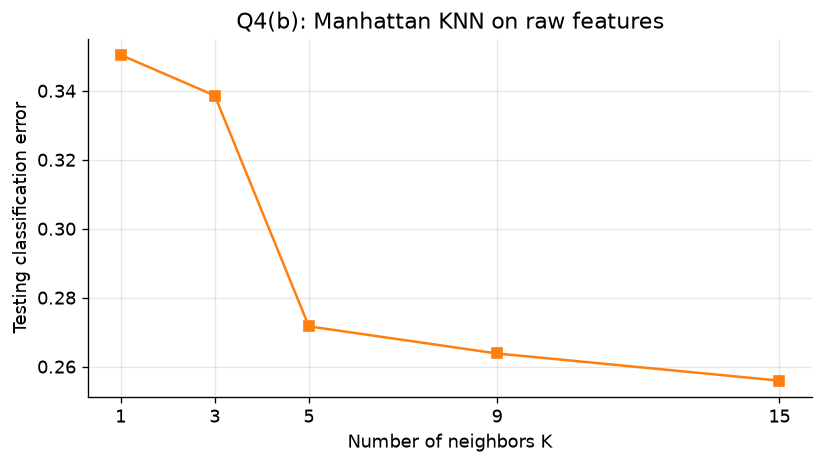

In [25]:
q4_raw_manhattan = q4_knn_errors(
    q4_X_train, q4_y_train, q4_X_test, q4_y_test, q4_small_grid, "manhattan"
)
display(q4_raw_manhattan.round(6))
plt.figure(figsize=(7, 4))
plt.plot(q4_raw_manhattan["K"], q4_raw_manhattan["Test error"], "s-", color="tab:orange")
plt.xticks(q4_small_grid)
plt.xlabel("Number of neighbors K")
plt.ylabel("Testing classification error")
plt.title("Q4(b): Manhattan KNN on raw features")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


#### c) Repeat the above using a Logistic Regression Classifier, and compare its testing error with those of the K Nearest Neighbor Classifiers. Do you observe any difference? Why?

In [26]:
# Keep the original features for comparison with (a) and (b).
# L2 regularization with C=1, an intercept, and lbfgs are the usual defaults.
# Raise the iteration limit so the optimizer can converge on unscaled features.
q4_lr = LogisticRegression(C=1.0, fit_intercept=True, solver="lbfgs",
                           tol=1e-4, max_iter=10000)
q4_lr.fit(q4_X_train, q4_y_train)
q4_lr_error = np.mean(q4_lr.predict(q4_X_test) != q4_y_test)
print(f"Logistic regression testing error: {q4_lr_error:.6f} ({q4_lr_error:.2%})")
print(f"Optimizer iterations: {q4_lr.n_iter_[0]} / {q4_lr.max_iter}")
q4_raw_comparison = pd.concat([q4_raw_euclidean, q4_raw_manhattan], ignore_index=True)
q4_raw_comparison["Logistic error"] = q4_lr_error
display(q4_raw_comparison.round(6))
display(Markdown(
    "**Comparison.** Logistic regression has lower testing error than every raw-feature "
    "KNN fit in this grid. It learns a global linear log-odds function and estimates "
    "feature coefficients from all the training observations. KNN uses local votes; "
    "on the raw features, measurements with large numerical scales dominate its "
    "distances and can make its neighborhoods less informative. Small K also has "
    "high variance. These considerations explain why logistic regression can do "
    "better here, but do not guarantee that it will outperform KNN on other datasets."
))


Logistic regression testing error: 0.220472 (22.05%)
Optimizer iterations: 123 / 10000


,Distance,K,Test mistakes,Test error,Logistic error
0,euclidean,1,95,0.374016,0.220472
1,euclidean,3,79,0.311024,0.220472
2,euclidean,5,68,0.267717,0.220472
3,euclidean,9,62,0.244094,0.220472
4,euclidean,15,67,0.263780,0.220472
5,manhattan,1,89,0.350394,0.220472
6,manhattan,3,86,0.338583,0.220472
7,manhattan,5,69,0.271654,0.220472
8,manhattan,9,67,0.263780,0.220472
9,manhattan,15,65,0.255906,0.220472


**Comparison.** Logistic regression has lower testing error than every raw-feature KNN fit in this grid. It learns a global linear log-odds function and estimates feature coefficients from all the training observations. KNN uses local votes; on the raw features, measurements with large numerical scales dominate its distances and can make its neighborhoods less informative. Small K also has high variance. These considerations explain why logistic regression can do better here, but do not guarantee that it will outperform KNN on other datasets.

#### d) The Euclidean distance is dominated by whichever features happen to have the largest numerical scale, so K Nearest Neighbor should be applied to standardized features.

Standardize the training set, standardize the testing set using the statistics of the training set, and repeat a) and b) on the standardized data over a wider grid $K \in \{1, 3, 5, 9, 15, 25, 41, 61, 81, 101\}$. Plot the classification error vs $K$ for both distances on the same figure, and report the best $K$ and its error for each. How does standardization change the results at small $K$?

Distance,euclidean,manhattan
K,,
1,0.291339,0.307087
3,0.271654,0.283465
5,0.251969,0.251969
9,0.244094,0.255906
15,0.248031,0.228346
25,0.248031,0.244094
41,0.240157,0.248031
61,0.244094,0.255906
81,0.240157,0.283465


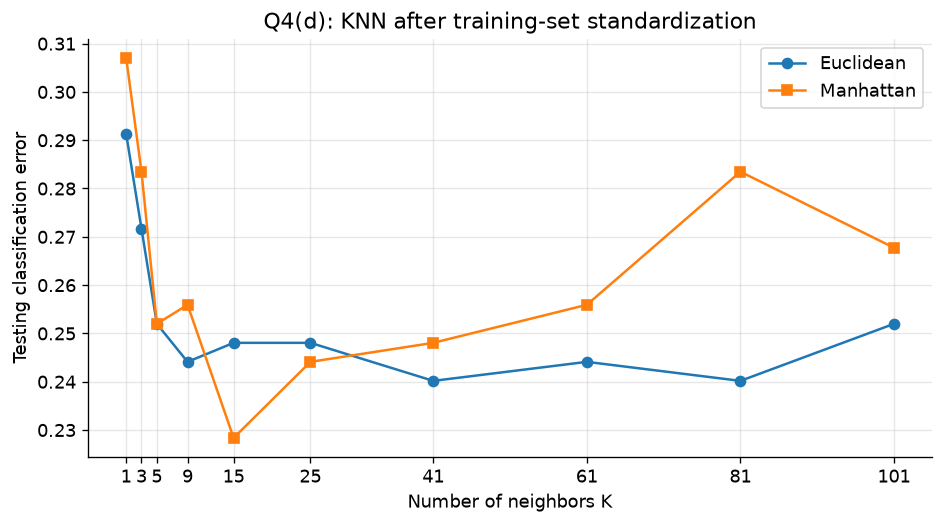

,Distance,Best K (all ties),Test mistakes,Best test error
0,euclidean,"[41, 81]",61,0.240157
1,manhattan,[15],58,0.228346


,Distance,K,Test error (raw),Test error (standardized),Change in test error
0,euclidean,1,0.374016,0.291339,-0.082677
1,euclidean,3,0.311024,0.271654,-0.039370
2,euclidean,5,0.267717,0.251969,-0.015748
3,euclidean,9,0.244094,0.244094,0.000000
4,euclidean,15,0.263780,0.248031,-0.015748
5,manhattan,1,0.350394,0.307087,-0.043307
6,manhattan,3,0.338583,0.283465,-0.055118
7,manhattan,5,0.271654,0.251969,-0.019685
8,manhattan,9,0.263780,0.255906,-0.007874
9,manhattan,15,0.255906,0.228346,-0.027559


In [27]:
q4_scaler = StandardScaler()
q4_X_train_std = q4_scaler.fit_transform(q4_X_train)
q4_X_test_std = q4_scaler.transform(q4_X_test)
q4_wide_grid = [1, 3, 5, 9, 15, 25, 41, 61, 81, 101]
q4_std_euclidean = q4_knn_errors(
    q4_X_train_std, q4_y_train, q4_X_test_std, q4_y_test, q4_wide_grid, "euclidean"
)
q4_std_manhattan = q4_knn_errors(
    q4_X_train_std, q4_y_train, q4_X_test_std, q4_y_test, q4_wide_grid, "manhattan"
)
q4_std_results = pd.concat([q4_std_euclidean, q4_std_manhattan], ignore_index=True)
display(q4_std_results.pivot(index="K", columns="Distance", values="Test error")
        .reindex(q4_wide_grid).round(6))

plt.figure(figsize=(8, 4.5))
for q4_metric, q4_marker in [("euclidean", "o"), ("manhattan", "s")]:
    q4_part = q4_std_results[q4_std_results["Distance"] == q4_metric]
    plt.plot(q4_part["K"], q4_part["Test error"], marker=q4_marker,
             label=q4_metric.capitalize())
plt.xticks(q4_wide_grid)
plt.xlabel("Number of neighbors K")
plt.ylabel("Testing classification error")
plt.title("Q4(d): KNN after training-set standardization")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Report all tied minimizers, not just the first K returned by argmin.
q4_best_rows = []
for q4_metric in ["euclidean", "manhattan"]:
    q4_part = q4_std_results[q4_std_results["Distance"] == q4_metric]
    q4_minimum = q4_part["Test mistakes"].min()
    q4_winners = q4_part.loc[q4_part["Test mistakes"] == q4_minimum, "K"].tolist()
    q4_best_rows.append({"Distance": q4_metric, "Best K (all ties)": str(q4_winners),
                         "Test mistakes": q4_minimum,
                         "Best test error": q4_minimum / len(q4_y_test)})
display(pd.DataFrame(q4_best_rows).round(6))

q4_scaling_comparison = pd.concat([q4_raw_euclidean, q4_raw_manhattan]).merge(
    q4_std_results, on=["Distance", "K"], suffixes=(" (raw)", " (standardized)")
)
q4_scaling_comparison["Change in test error"] = (
    q4_scaling_comparison["Test error (standardized)"]
    - q4_scaling_comparison["Test error (raw)"]
)
display(q4_scaling_comparison[["Distance", "K", "Test error (raw)",
    "Test error (standardized)", "Change in test error"]].round(6))


The best standardized Euclidean error is **61/254 = 0.240157** at **K = 41 and K = 81 (a tie)**.
The best standardized Manhattan error is **58/254 = 0.228346** at **K = 15**.

At small K, standardization improves both distances. For Euclidean distance, the errors at K = 1, 3, and 5 decrease from **0.374016, 0.311024, 0.267717** to **0.291339, 0.271654, 0.251969**. For Manhattan distance, they decrease from **0.350394, 0.338583, 0.271654** to **0.307087, 0.283465, 0.251969**. The K = 1 improvements are about **8.27** and **4.33 percentage points**, respectively.

Dividing each feature by its training-set standard deviation changes the neighborhoods: a feature's contribution is measured relative to its observed variation instead of its original units. This reduces domination by large-scale features (for example, insulin) for both distances. It does not guarantee an improvement for every possible dataset or K. The standardized Manhattan model substantially narrows the gap to logistic regression, although its minimum testing error (0.228346) is still slightly above logistic regression's 0.220472. This is only a difference of two testing observations.


#### e) Looking at your curve from d): which range of $K$ is dominated by variance, and which by bias? 

Also report the KNN classification error on the *training* set at $K = 1, 3, 15, 101$. Explain why you cannot choose $K$ by minimizing the training error.

In [28]:
q4_training_rows = []
for q4_metric in ["euclidean", "manhattan"]:
    for q4_k in [1, 3, 15, 101]:
        q4_model = KNeighborsClassifier(n_neighbors=q4_k, metric=q4_metric, weights="uniform")
        q4_model.fit(q4_X_train_std, q4_y_train)
        # Passing X_train explicitly includes the query point itself among its neighbors.
        q4_train_wrong = np.count_nonzero(q4_model.predict(q4_X_train_std) != q4_y_train)
        q4_test_wrong = np.count_nonzero(q4_model.predict(q4_X_test_std) != q4_y_test)
        q4_training_rows.append({"Distance": q4_metric, "K": q4_k,
            "Train mistakes": q4_train_wrong,
            "Training error": q4_train_wrong / len(q4_y_train),
            "Testing error": q4_test_wrong / len(q4_y_test)})
q4_training_results = pd.DataFrame(q4_training_rows)
display(q4_training_results.round(6))
display(Markdown(
    "**Bias and variance.** The smallest neighborhoods (roughly K = 1–5) are "
    "most sensitive to individual observations and local noise, so variance is the "
    "main concern. Large neighborhoods (roughly K = 61–101 in this grid) smooth "
    "over more distinct regions and have greater bias and lower variance. "
    "The finite testing curves need not be monotone, and the curves alone do not "
    "identify a formal bias–variance decomposition. In particular, Euclidean KNN "
    "ties for its best error at K = 41 and K = 81, so it would be too strong to "
    "claim that every large K already underfits. The rise in Manhattan error "
    "above its K = 15 minimum, and both errors at K = 101 relative to their "
    "minima, are consistent with increasing bias from excessive smoothing.\n\n"
    "**Why training error is unsuitable for choosing K.** With K = 1, each training "
    "point is its own nearest neighbor when we call `predict(X_train)`, yielding "
    "zero training error here. This is a resubstitution estimate, not a "
    "leave-one-out estimate, and hides the model's poor generalization. Minimizing "
    "training error therefore favors an overly flexible classifier. Select K and "
    "the distance metric using validation data or cross-validation, fitting the "
    "scaler separately within each training fold. Evaluate the selected model "
    "once on an untouched test set. The best testing errors reported in (d) "
    "are descriptive results requested by the exercise; using that same test "
    "set to select K makes the selected error optimistically biased."
))


,Distance,K,Train mistakes,Training error,Testing error
0,euclidean,1,0,0.000000,0.291339
1,euclidean,3,79,0.153996,0.271654
2,euclidean,15,113,0.220273,0.248031
3,euclidean,101,141,0.274854,0.251969
4,manhattan,1,0,0.000000,0.307087
5,manhattan,3,80,0.155945,0.283465
6,manhattan,15,118,0.230019,0.228346
7,manhattan,101,143,0.278752,0.267717


**Bias and variance.** The smallest neighborhoods (roughly K = 1–5) are most sensitive to individual observations and local noise, so variance is the main concern. Large neighborhoods (roughly K = 61–101 in this grid) smooth over more distinct regions and have greater bias and lower variance. The finite testing curves need not be monotone, and the curves alone do not identify a formal bias–variance decomposition. In particular, Euclidean KNN ties for its best error at K = 41 and K = 81, so it would be too strong to claim that every large K already underfits. The rise in Manhattan error above its K = 15 minimum, and both errors at K = 101 relative to their minima, are consistent with increasing bias from excessive smoothing.

**Why training error is unsuitable for choosing K.** With K = 1, each training point is its own nearest neighbor when we call `predict(X_train)`, yielding zero training error here. This is a resubstitution estimate, not a leave-one-out estimate, and hides the model's poor generalization. Minimizing training error therefore favors an overly flexible classifier. Select K and the distance metric using validation data or cross-validation, fitting the scaler separately within each training fold. Evaluate the selected model once on an untouched test set. The best testing errors reported in (d) are descriptive results requested by the exercise; using that same test set to select K makes the selected error optimistically biased.

### 5. Bayes Error Rate

* In this question we use a simulated dataset, so that the optimal classifier and its error rate are known exactly and every classifier can be compared against them.
* The data are generated as in the lecture:

<center>$Y \sim \text{Bernoulli}(0.5)$, and $X\,|\,Y=k \sim N(\mu_k, \Sigma)$ for $k = 0, 1$,</center>

with
<center>$\mu_0 = (0, 0)^\top$, $\mu_1 = (1.2, 0)^\top$, $\Sigma = \begin{pmatrix} 1 & 0.8 \\ 0.8 & 1\end{pmatrix}$.</center>

* `Q5_train.csv` contains 20000 training points and `Q5_test.csv` contains 50000 testing points. The first two columns are $X_1$ and $X_2$ and the last column is the label.

#### a) Load the data and confirm the class balance. Make a scatter plot of the first 2000 training points, coloured by label.

,Split,Class,Count,Proportion
0,Train,0,10074,0.50370
1,Train,1,9926,0.49630
2,Test,0,25226,0.50452
3,Test,1,24774,0.49548


Both splits are approximately balanced, as expected from Bernoulli(0.5).


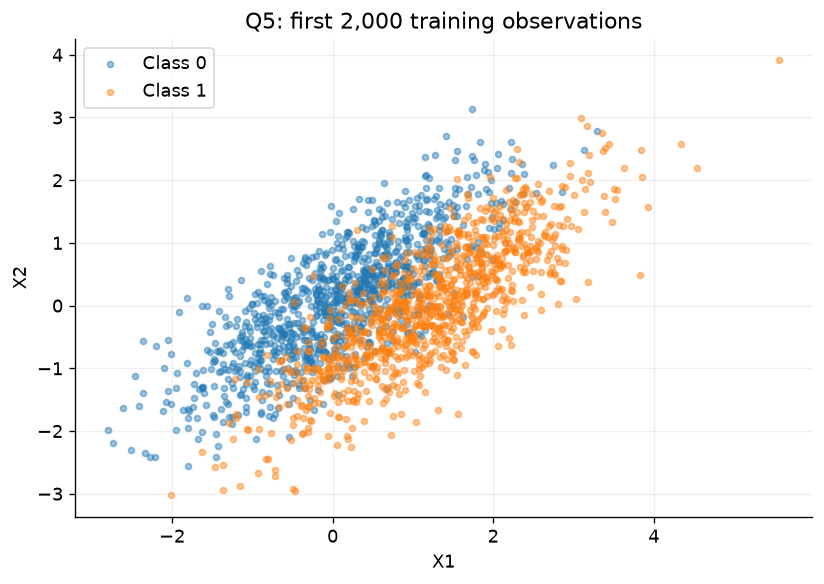

In [29]:
from scipy.stats import norm
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

q5_X_train, q5_y_train, q5_names = load_xy('Q5_train.csv')
q5_X_test, q5_y_test, _ = load_xy('Q5_test.csv')
q5_y_train = q5_y_train.astype(int)
q5_y_test = q5_y_test.astype(int)
assert q5_X_train.shape == (20000, 2)
assert q5_X_test.shape == (50000, 2)
q5_balance = pd.DataFrame([
    {'Split': split, 'Class': label, 'Count': int(np.sum(y == label)),
     'Proportion': np.mean(y == label)}
    for split, y in [('Train', q5_y_train), ('Test', q5_y_test)]
    for label in (0, 1)
])
display(q5_balance)
print('Both splits are approximately balanced, as expected from Bernoulli(0.5).')

fig, ax = plt.subplots(figsize=(7, 5))
for label, color in [(0, 'tab:blue'), (1, 'tab:orange')]:
    q5_mask = q5_y_train[:2000] == label
    ax.scatter(q5_X_train[:2000][q5_mask, 0], q5_X_train[:2000][q5_mask, 1],
               s=13, alpha=0.45, color=color, label=f'Class {label}')
ax.set(xlabel='X1', ylabel='X2', title='Q5: first 2,000 training observations')
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


#### b) Because both classes share the same covariance matrix $\Sigma$ and $P(Y=0) = P(Y=1) = 0.5$, the optimal Bayes classifier has a linear decision boundary and its error rate can be written in closed form:

<center>$P(f^*(X) \neq Y) = \Phi\!\left(-\frac{\Delta}{2}\right)$, where $\Delta = \sqrt{(\mu_1-\mu_0)^\top \Sigma^{-1} (\mu_1-\mu_0)}$</center>

is the Mahalanobis distance between the two class means and $\Phi$ is the standard normal CDF. Compute $\Delta$ and the Bayes error rate for the parameters above. *Hint:* `scipy.stats.norm.cdf`.

In [30]:
q5_mu0 = np.array([0.0, 0.0])
q5_mu1 = np.array([1.2, 0.0])
q5_sigma = np.array([[1.0, 0.8], [0.8, 1.0]])
q5_difference = q5_mu1 - q5_mu0
q5_delta = np.sqrt(q5_difference @ np.linalg.solve(q5_sigma, q5_difference))
q5_bayes_rate = norm.cdf(-q5_delta / 2)
q5_bayes_w = np.linalg.solve(q5_sigma, q5_difference)
q5_bayes_b = -0.5 * (q5_mu1 + q5_mu0) @ q5_bayes_w
print(f'Mahalanobis distance Delta = {q5_delta:.10f}')
print(f'Bayes error rate = Phi(-1) = {q5_bayes_rate:.10f} ({100*q5_bayes_rate:.4f}%)')
print(f'Bayes score coefficients: {q5_bayes_w}; intercept: {q5_bayes_b:.10f}')
display(Markdown(r"""
Since $\Sigma^{-1}=\frac{1}{0.36}\begin{pmatrix}1&-0.8\\-0.8&1\end{pmatrix}$,
$\Delta^2=1.2^2/0.36=4$, so $\Delta=2$ and $R^*=\Phi(-1)$.
The Bayes rule predicts class 1 exactly when
$\frac{10}{3}X_1-\frac{8}{3}X_2-2\geq0$, or equivalently $X_1-0.8X_2\geq0.6$.
"""))


Mahalanobis distance Delta = 2.0000000000
Bayes error rate = Phi(-1) = 0.1586552539 (15.8655%)
Bayes score coefficients: [ 3.33333333 -2.66666667]; intercept: -2.0000000000



Since $\Sigma^{-1}=\frac{1}{0.36}\begin{pmatrix}1&-0.8\\-0.8&1\end{pmatrix}$,
$\Delta^2=1.2^2/0.36=4$, so $\Delta=2$ and $R^*=\Phi(-1)$.
The Bayes rule predicts class 1 exactly when
$\frac{10}{3}X_1-\frac{8}{3}X_2-2\geq0$, or equivalently $X_1-0.8X_2\geq0.6$.


#### c) Train Linear Discriminant Analysis, Gaussian Naive Bayes and Logistic Regression on the first $n$ training points, for $n \in \{100, 200, 500, 1000, 2000, 5000, 10000, 20000\}$, and evaluate each on the full testing set.

Plot the testing classification error vs $n$ (use a logarithmic scale for $n$) for the three classifiers, and draw the Bayes error rate from b) as a horizontal reference line.

Classifier,LDA,Gaussian NB,Logistic regression
n,,,
100,0.16404,0.27762,0.16374
200,0.16482,0.27092,0.16424
500,0.15898,0.27338,0.15986
1000,0.15968,0.28056,0.16026
2000,0.15846,0.26338,0.15794
5000,0.15794,0.27034,0.15812
10000,0.15802,0.27116,0.15798
20000,0.15816,0.27478,0.15826


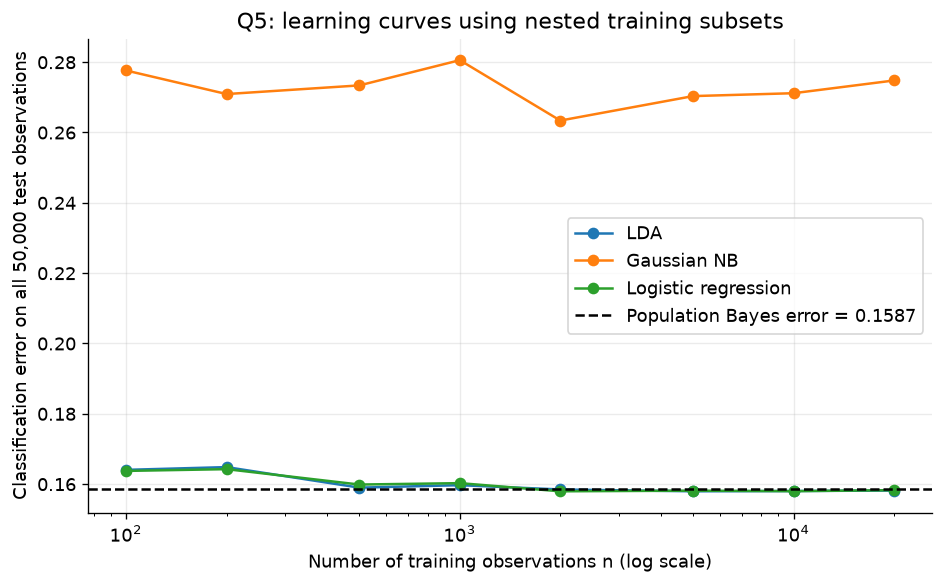

Known Bayes classifier error on this finite test set: 0.158220
Binomial test-error standard error at the Bayes rate: 0.001634
Best classifier at n=20,000: LDA, error = 0.158160
Its difference from population Bayes error: -0.000495 (-0.30 standard errors)


In [31]:
q5_sizes = [100, 200, 500, 1000, 2000, 5000, 10000, 20000]
q5_rows = []
for q5_n in q5_sizes:
    # The data are nested: each fit uses exactly the first n original rows.
    # Keep the same logistic solver, C, and tolerance at every sample size.
    q5_models = {
        'LDA': LinearDiscriminantAnalysis(),
        'Gaussian NB': GaussianNB(),
        'Logistic regression': LogisticRegression(
            solver='lbfgs', C=1.0, tol=1e-4, max_iter=10000)
    }
    for q5_name, q5_model in q5_models.items():
        q5_model.fit(q5_X_train[:q5_n], q5_y_train[:q5_n])
        if q5_name == 'Logistic regression':
            assert np.max(q5_model.n_iter_) < q5_model.max_iter
        q5_prediction = q5_model.predict(q5_X_test)
        q5_rows.append({'n': q5_n, 'Classifier': q5_name,
                        'Test errors': int(np.sum(q5_prediction != q5_y_test)),
                        'Test error': np.mean(q5_prediction != q5_y_test)})
q5_results = pd.DataFrame(q5_rows)
q5_curve = q5_results.pivot(index='n', columns='Classifier', values='Test error')
q5_curve = q5_curve[['LDA', 'Gaussian NB', 'Logistic regression']]
display(q5_curve)

fig, ax = plt.subplots(figsize=(8, 5))
for q5_name in q5_curve.columns:
    ax.plot(q5_curve.index, q5_curve[q5_name], marker='o', label=q5_name)
ax.axhline(q5_bayes_rate, linestyle='--', color='black',
           label=f'Population Bayes error = {q5_bayes_rate:.4f}')
ax.set_xscale('log')
ax.set(xlabel='Number of training observations n (log scale)',
       ylabel='Classification error on all 50,000 test observations',
       title='Q5: learning curves using nested training subsets')
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

q5_bayes_prediction = (q5_X_test @ q5_bayes_w + q5_bayes_b >= 0).astype(int)
q5_empirical_bayes = np.mean(q5_bayes_prediction != q5_y_test)
q5_test_se = np.sqrt(q5_bayes_rate * (1 - q5_bayes_rate) / len(q5_y_test))
q5_best_last_name = q5_curve.iloc[-1].idxmin()
q5_best_last = q5_curve.iloc[-1].min()
print(f'Known Bayes classifier error on this finite test set: {q5_empirical_bayes:.6f}')
print(f'Binomial test-error standard error at the Bayes rate: {q5_test_se:.6f}')
print(f'Best classifier at n=20,000: {q5_best_last_name}, error = {q5_best_last:.6f}')
print(f'Its difference from population Bayes error: {q5_best_last - q5_bayes_rate:+.6f} '
      f'({(q5_best_last - q5_bayes_rate) / q5_test_se:+.2f} standard errors)')


#### d) No classifier in your plot goes meaningfully below the Bayes error rate. Why is that guaranteed?

Let $\eta(x)=P(Y=1\mid X=x)$. Conditional on $X=x$, predicting 0 has error
$\eta(x)$ and predicting 1 has error $1-\eta(x)$. The Bayes classifier chooses
the smaller one, so its population risk is
$R^*=E[\min\{\eta(X),1-\eta(X)\}]$. Every classifier $f$ therefore satisfies
$R(f)\geq R^*$, including a classifier fitted to a particular independent training set.
Equivalently,
$R(f)-R^*=E[|2\eta(X)-1|\mathbf{1}\{f(X)\ne f^*(X)\}]\geq0$.

This is a guarantee for **population classification error**, not for the error
measured on one finite test set. A measured test error can be below $R^*$ by
sampling variation. Thus the plot is consistent with the guarantee, but the
guarantee does not prohibit a point from falling slightly below the dashed line.


#### e) As $n$ grows, two of the three classifiers approach the Bayes error rate and one does not. Identify which is which and explain why, in terms of the assumptions each classifier makes about $P(X\,|\,Y)$.

Your best classifier may land a little *below* the dashed line at large $n$. The testing error is itself estimated from a finite sample: with 50000 testing points its standard error at the Bayes rate is about 0.0016. Does that explain the gap you see?

In [32]:
q5_gnb_limit = norm.cdf(-0.6)
display(Markdown(
    f'**LDA and logistic regression approach the Bayes rate.** LDA is correctly '
    f'specified because the true class-conditional distributions are Gaussian with '
    f'a shared full covariance. Logistic regression models the posterior directly; '
    f'it does not require a class-conditional Gaussian assumption. Here the true '
    f'log odds are linear, so its model is also correctly specified. With fixed '
    f'`C=1`, the effective penalty relative to the increasing total data loss '
    f'vanishes as the sample size grows.\n\n'
    f'**Gaussian Naive Bayes does not approach the Bayes rate.** It discards the '
    f'within-class correlation of 0.8 by using diagonal covariance matrices. '
    f'Asymptotically it learns equal unit variances and the correct means, but its '
    f'rule becomes $X_1 \\geq 0.6$, ignoring the information in $X_2$ that removes '
    f'correlated noise. Its limiting error is '
    f'$\\Phi(-0.6)={q5_gnb_limit:.6f}$, versus '
    f'$\\Phi(-1)={q5_bayes_rate:.6f}$ for the optimal rule. '
    f'More observations reduce estimation error but cannot remove this model bias.\n\n'
    f'At $n=20{{,}}000$, the lowest measured error is **{q5_best_last:.6f}** '
    f'({q5_best_last_name}). Its difference from the population Bayes rate is '
    f'{q5_best_last - q5_bayes_rate:+.6f}, or '
    f'{(q5_best_last - q5_bayes_rate)/q5_test_se:+.2f} approximate standard errors. '
    f'The standard error is $\\sqrt{{R^*(1-R^*)/50000}}={q5_test_se:.6f}$; '
    f'a rough 95% sampling margin is $1.96\\,SE={1.96*q5_test_se:.6f}$. '
    f'The known Bayes rule itself has empirical error {q5_empirical_bayes:.6f} '
    f'on these same test observations. This makes any comparably small gap '
    f'plausible as finite-test sampling fluctuation, not evidence of beating '
    f'the population optimum. The curve need not be monotone because fitted '
    f'parameters fluctuate as new training rows are added.'
))


**LDA and logistic regression approach the Bayes rate.** LDA is correctly specified because the true class-conditional distributions are Gaussian with a shared full covariance. Logistic regression models the posterior directly; it does not require a class-conditional Gaussian assumption. Here the true log odds are linear, so its model is also correctly specified. With fixed `C=1`, the effective penalty relative to the increasing total data loss vanishes as the sample size grows.

**Gaussian Naive Bayes does not approach the Bayes rate.** It discards the within-class correlation of 0.8 by using diagonal covariance matrices. Asymptotically it learns equal unit variances and the correct means, but its rule becomes $X_1 \geq 0.6$, ignoring the information in $X_2$ that removes correlated noise. Its limiting error is $\Phi(-0.6)=0.274253$, versus $\Phi(-1)=0.158655$ for the optimal rule. More observations reduce estimation error but cannot remove this model bias.

At $n=20{,}000$, the lowest measured error is **0.158160** (LDA). Its difference from the population Bayes rate is -0.000495, or -0.30 approximate standard errors. The standard error is $\sqrt{R^*(1-R^*)/50000}=0.001634$; a rough 95% sampling margin is $1.96\,SE=0.003202$. The known Bayes rule itself has empirical error 0.158220 on these same test observations. This makes any comparably small gap plausible as finite-test sampling fluctuation, not evidence of beating the population optimum. The curve need not be monotone because fitted parameters fluctuate as new training rows are added.

### 6. Bayes' Rule and the Base Rate

* Q5 used the Bayes classifier with continuous features. This question uses it with a single binary feature, in a setting where the answer surprises almost everyone.
* A disease affects **0.1%** of the population, so $P(D) = 0.001$. A diagnostic test $T$ is **99% accurate** in the following sense: it is positive for 99% of the people who have the disease, $P(T = + \mid D) = 0.99$, and negative for 99% of the people who do not, $P(T = - \mid \neg D) = 0.99$. (Check for yourself that its overall accuracy is then exactly 99%, whatever the prevalence.)
* No data file is needed; you will simulate the population yourself in b).

#### a) A person is picked at random from the population and tests positive. Using Bayes' rule, compute the probability that they actually have the disease, $P(D \mid T = +)$. Show your steps. Then compute $P(D \mid T = -)$.

In [33]:
q6_prevalence = 0.001
q6_sensitivity = 0.99
q6_specificity = 0.99
q6_false_positive = 1 - q6_specificity
q6_false_negative = 1 - q6_sensitivity
q6_positive_probability = (q6_sensitivity * q6_prevalence
                           + q6_false_positive * (1 - q6_prevalence))
q6_negative_probability = (q6_false_negative * q6_prevalence
                           + q6_specificity * (1 - q6_prevalence))
q6_p_d_positive = q6_sensitivity * q6_prevalence / q6_positive_probability
q6_p_d_negative = q6_false_negative * q6_prevalence / q6_negative_probability
q6_accuracy = (q6_sensitivity * q6_prevalence
               + q6_specificity * (1 - q6_prevalence))
display(Markdown(r"""
By Bayes' rule,
$$P(D\mid+) = \frac{P(+\mid D)P(D)}{P(+\mid D)P(D)+P(+\mid\neg D)P(\neg D)}
=\frac{0.99(0.001)}{0.99(0.001)+0.01(0.999)}
=\frac{0.00099}{0.01098}\approx0.0901639344.$$
Thus a positive test gives about **9.0164%** probability of disease.
Similarly,
$$P(D\mid-) = \frac{0.01(0.001)}{0.01(0.001)+0.99(0.999)}
=\frac{0.00001}{0.98902}\approx0.0000101110,$$
or about **0.00101110%**.
The overall test accuracy at prevalence $p$ is
$0.99p+0.99(1-p)=0.99$, irrespective of $p$.
"""))
print(f'P(D | +) = {q6_p_d_positive:.10f} ({100*q6_p_d_positive:.6f}%)')
print(f'P(D | -) = {q6_p_d_negative:.10f} ({100*q6_p_d_negative:.8f}%)')
print(f'Overall population test accuracy = {q6_accuracy:.6f}')



By Bayes' rule,
$$P(D\mid+) = \frac{P(+\mid D)P(D)}{P(+\mid D)P(D)+P(+\mid\neg D)P(\neg D)}
=\frac{0.99(0.001)}{0.99(0.001)+0.01(0.999)}
=\frac{0.00099}{0.01098}\approx0.0901639344.$$
Thus a positive test gives about **9.0164%** probability of disease.
Similarly,
$$P(D\mid-) = \frac{0.01(0.001)}{0.01(0.001)+0.99(0.999)}
=\frac{0.00001}{0.98902}\approx0.0000101110,$$
or about **0.00101110%**.
The overall test accuracy at prevalence $p$ is
$0.99p+0.99(1-p)=0.99$, irrespective of $p$.


P(D | +) = 0.0901639344 (9.016393%)
P(D | -) = 0.0000101110 (0.00101110%)
Overall population test accuracy = 0.990000


#### b) Verify a) by simulation. Draw the disease status of $10^6$ people with prevalence 0.001, then draw each person's test result from the conditional probabilities above (use a fixed seed, e.g. `numpy.random.default_rng(6740)`). Report the number of people in each of the four (status, result) combinations, and estimate $P(D \mid T = +)$ as the fraction of positive tests that belong to diseased people. Compare with a).

In [34]:
q6_rng = np.random.default_rng(6740)
q6_population_size = 1_000_000
q6_disease = q6_rng.random(q6_population_size) < q6_prevalence
q6_positive = q6_rng.random(q6_population_size) < np.where(
    q6_disease, q6_sensitivity, q6_false_positive)
q6_tp = int(np.sum(q6_disease & q6_positive))
q6_fn = int(np.sum(q6_disease & ~q6_positive))
q6_fp = int(np.sum(~q6_disease & q6_positive))
q6_tn = int(np.sum(~q6_disease & ~q6_positive))
q6_counts = pd.DataFrame({
    'Disease status': ['Disease', 'Disease', 'No disease', 'No disease'],
    'Test result': ['Positive', 'Negative', 'Positive', 'Negative'],
    'Simulated count': [q6_tp, q6_fn, q6_fp, q6_tn],
    'Expected count': q6_population_size * np.array([
        q6_prevalence*q6_sensitivity,
        q6_prevalence*q6_false_negative,
        (1-q6_prevalence)*q6_false_positive,
        (1-q6_prevalence)*q6_specificity])
})
assert q6_counts['Simulated count'].sum() == q6_population_size
display(q6_counts)
q6_empirical_positive = q6_tp / (q6_tp + q6_fp)
q6_empirical_negative = q6_fn / (q6_fn + q6_tn)
q6_positive_se = np.sqrt(q6_p_d_positive*(1-q6_p_d_positive)/(q6_tp+q6_fp))
print(f'Estimated P(D | +) = {q6_tp}/({q6_tp}+{q6_fp}) = {q6_empirical_positive:.8f}')
print(f'Exact P(D | +) = {q6_p_d_positive:.8f}; difference = '
      f'{q6_empirical_positive-q6_p_d_positive:+.8f}')
print(f'Approximate Monte Carlo standard error for P(D | +): {q6_positive_se:.8f}')
print(f'Estimated P(D | -) = {q6_empirical_negative:.8f}; exact = {q6_p_d_negative:.8f}')
print('Small differences from the exact probabilities are Monte Carlo sampling error.')


,Disease status,Test result,Simulated count,Expected count
0,Disease,Positive,958,990.0
1,Disease,Negative,9,10.0
2,No disease,Positive,9938,9990.0
3,No disease,Negative,989095,989010.0


Estimated P(D | +) = 958/(958+9938) = 0.08792217
Exact P(D | +) = 0.09016393; difference = -0.00224176
Approximate Monte Carlo standard error for P(D | +): 0.00274388
Estimated P(D | -) = 0.00000910; exact = 0.00001011
Small differences from the exact probabilities are Monte Carlo sampling error.


#### c) Treat the test result as a one-dimensional feature and the disease status as the label, exactly as in Lecture 2. Write down the optimal Bayes classifier $f^*(t)$ — the one that predicts disease if and only if $P(D \mid T = t) \ge 0.5$ — and its error rate. Compare that error rate with two other classifiers evaluated on your simulated population: "trust the test" (predict disease iff $T = +$) and "always predict no disease". Which is best under classification error? Is the 99%-accurate test useful at all, and if so, for what?

In [35]:
q6_bayes_predictions = np.where(
    q6_positive, q6_p_d_positive >= 0.5, q6_p_d_negative >= 0.5)
q6_always_negative = np.zeros(q6_population_size, dtype=bool)
q6_classifier_comparison = pd.DataFrame([
    {'Classifier': name,
     'Simulated misclassifications': int(np.sum(predictions != q6_disease)),
     'Simulated error': np.mean(predictions != q6_disease),
     'Population error': population_error}
    for name, predictions, population_error in [
        ('Bayes classifier', q6_bayes_predictions, q6_prevalence),
        ('Trust the test', q6_positive, 1-q6_accuracy),
        ('Always predict no disease', q6_always_negative, q6_prevalence)
    ]
])
display(q6_classifier_comparison)


,Classifier,Simulated misclassifications,Simulated error,Population error
0,Bayes classifier,967,0.000967,0.001
1,Trust the test,9947,0.009947,0.010
2,Always predict no disease,967,0.000967,0.001


Both posterior probabilities in (a) are below $0.5$, so
$$f^*(+)=f^*(-)=0.$$
The Bayes classifier always predicts no disease. Its population error is
$P(D)=0.001$ (**0.1%**), identical to the always-negative classifier. Trusting
the test has population error
$P(D)P(-\mid D)+P(\neg D)P(+\mid\neg D)=0.00001+0.00999=0.01$ (**1%**).
Thus the first and third rules tie for the smallest ordinary classification error.
In the simulation they make exactly the same predictions and errors.

The test is still informative: a positive result increases disease probability
from 0.1% to about 9.02%, and a negative result decreases it to about 0.00101%.
It can support risk ranking, follow-up testing, or decisions with unequal costs
for false negatives and false positives. Ordinary classification error weights
the two error types equally and hides the fact that the always-negative rule
misses every diseased person. A different loss can yield a different decision
threshold and make acting on a positive test optimal in this hypothetical model.


#### d) Write Bayes' rule in odds form: posterior odds $=$ prior odds $\times$ likelihood ratio, where the likelihood ratio of a positive test is $P(T = + \mid D) \,/\, P(T = + \mid \neg D)$. Compute the prior odds, the likelihood ratio and the posterior odds, and check that you recover a). Then use the odds form to find how high the prevalence must be before a positive test makes disease more likely than not, i.e. $P(D \mid T = +) \ge 0.5$.

In [36]:
q6_prior_odds = q6_prevalence / (1-q6_prevalence)
q6_positive_lr = q6_sensitivity / q6_false_positive
q6_posterior_odds = q6_prior_odds * q6_positive_lr
q6_p_from_odds = q6_posterior_odds / (1+q6_posterior_odds)
q6_prevalence_threshold = 1 / (1 + q6_positive_lr)
display(Markdown(r"""
The odds form of Bayes' rule is
$$\frac{P(D\mid+)}{P(\neg D\mid+)}
=\frac{P(D)}{P(\neg D)}\frac{P(+\mid D)}{P(+\mid\neg D)}.$$
The prior odds are $0.001/0.999=1/999$, and the positive likelihood ratio is
$0.99/0.01=99$. Therefore the posterior odds are
$99/999=11/111\approx0.0990991$ and the posterior probability is
$\frac{99/999}{1+99/999}=99/1098\approx0.0901639$, agreeing with (a).

At prevalence $p$, a positive test yields posterior probability at least $0.5$
exactly when its posterior odds are at least 1:
$$99\frac{p}{1-p}\geq1 \quad\Longleftrightarrow\quad 100p\geq1
\quad\Longleftrightarrow\quad p\geq0.01.$$
Thus the threshold is **1% prevalence** (posterior exactly 50% at equality;
strictly greater than 50% requires prevalence strictly greater than 1%).
"""))
display(pd.DataFrame({
    'Quantity': ['Prior odds', 'Positive likelihood ratio', 'Posterior odds',
                 'Posterior probability from odds', 'Prevalence threshold'],
    'Value': [q6_prior_odds, q6_positive_lr, q6_posterior_odds,
              q6_p_from_odds, q6_prevalence_threshold]
}))



The odds form of Bayes' rule is
$$\frac{P(D\mid+)}{P(\neg D\mid+)}
=\frac{P(D)}{P(\neg D)}\frac{P(+\mid D)}{P(+\mid\neg D)}.$$
The prior odds are $0.001/0.999=1/999$, and the positive likelihood ratio is
$0.99/0.01=99$. Therefore the posterior odds are
$99/999=11/111\approx0.0990991$ and the posterior probability is
$\frac{99/999}{1+99/999}=99/1098\approx0.0901639$, agreeing with (a).

At prevalence $p$, a positive test yields posterior probability at least $0.5$
exactly when its posterior odds are at least 1:
$$99\frac{p}{1-p}\geq1 \quad\Longleftrightarrow\quad 100p\geq1
\quad\Longleftrightarrow\quad p\geq0.01.$$
Thus the threshold is **1% prevalence** (posterior exactly 50% at equality;
strictly greater than 50% requires prevalence strictly greater than 1%).


,Quantity,Value
0,Prior odds,0.001001
1,Positive likelihood ratio,99.000000
2,Posterior odds,0.099099
3,Posterior probability from odds,0.090164
4,Prevalence threshold,0.010000


#### e) The person takes the test a second time, and the two results are conditionally independent given the disease status — this is precisely the assumption behind Naive Bayes in Lecture 2. If both tests are positive, what is $P(D \mid +, +)$? How many independent positive tests would be needed to push the posterior probability above 99%? Finally, explain why conditional independence is a questionable assumption for repeated medical tests, and relate this to what happened to Gaussian Naive Bayes in Q5 e).

In [37]:
q6_k = np.arange(1, 4)
q6_repeated_odds = q6_prior_odds * q6_positive_lr**q6_k
q6_repeated_posterior = q6_repeated_odds / (1+q6_repeated_odds)
display(pd.DataFrame({'Independent positive tests': q6_k,
                      'Posterior odds': q6_repeated_odds,
                      'P(disease | all positive)': q6_repeated_posterior}))
q6_minimum_tests = int(np.floor(
    np.log(99/q6_prior_odds)/np.log(q6_positive_lr)) + 1)
print(f'Minimum number of independent positive tests for posterior >99%: {q6_minimum_tests}')
display(Markdown(r"""
Conditional independence applies **within each disease-status group**, so two
positive results have likelihoods $0.99^2$ if diseased and $0.01^2$ otherwise:
$$P(D\mid+,+)=\frac{0.001(0.99)^2}{0.001(0.99)^2+0.999(0.01)^2}
=\frac{0.0009801}{0.00108}=\boxed{0.9075}.$$
For $k$ independent positive tests, the posterior odds are $99^k/999$.
A posterior **strictly above 99%** requires odds $>99$, hence
$$\frac{99^k}{999}>99
\quad\Longleftrightarrow\quad
k>\frac{\log(99\cdot999)}{\log99}\approx2.503.$$
The smallest integer is **3**, giving a posterior of about **99.8971%**.

Repeated tests may remain correlated even after conditioning on disease status:
the same measurement method, sample, systematic interference, or persistent
person-specific factors can reproduce the same errors. Then likelihood ratios
cannot simply be multiplied; for identical perfectly dependent repeated results,
a second positive adds no information. Treating correlated positive results as
independent can overstate the evidence and produce overconfident probabilities.
In Q5, the features have conditional correlation 0.8, so Gaussian Naive Bayes also
uses an incorrect product of marginal likelihoods. There the resulting decision
boundary remains suboptimal even with unlimited training data. Both examples
show that more observations cannot correct a false conditional-independence
assumption; the joint likelihood must model the dependence appropriately.
"""))


,Independent positive tests,Posterior odds,P(disease | all positive)
0,1,0.099099,0.090164
1,2,9.810811,0.907500
2,3,971.270270,0.998971


Minimum number of independent positive tests for posterior >99%: 3



Conditional independence applies **within each disease-status group**, so two
positive results have likelihoods $0.99^2$ if diseased and $0.01^2$ otherwise:
$$P(D\mid+,+)=\frac{0.001(0.99)^2}{0.001(0.99)^2+0.999(0.01)^2}
=\frac{0.0009801}{0.00108}=\boxed{0.9075}.$$
For $k$ independent positive tests, the posterior odds are $99^k/999$.
A posterior **strictly above 99%** requires odds $>99$, hence
$$\frac{99^k}{999}>99
\quad\Longleftrightarrow\quad
k>\frac{\log(99\cdot999)}{\log99}\approx2.503.$$
The smallest integer is **3**, giving a posterior of about **99.8971%**.

Repeated tests may remain correlated even after conditioning on disease status:
the same measurement method, sample, systematic interference, or persistent
person-specific factors can reproduce the same errors. Then likelihood ratios
cannot simply be multiplied; for identical perfectly dependent repeated results,
a second positive adds no information. Treating correlated positive results as
independent can overstate the evidence and produce overconfident probabilities.
In Q5, the features have conditional correlation 0.8, so Gaussian Naive Bayes also
uses an incorrect product of marginal likelihoods. There the resulting decision
boundary remains suboptimal even with unlimited training data. Both examples
show that more observations cannot correct a false conditional-independence
assumption; the joint likelihood must model the dependence appropriately.
